# Clustering based on Gaussian Mixture Models

Packages

In [51]:
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
from typing import Union
from pathlib import Path
from scipy.linalg import eig
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.signal import detrend, butter, filtfilt
from typing import Dict, Tuple, List, Optional, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.linalg import eig
import warnings
warnings.filterwarnings("ignore")
from scipy.interpolate import interp1d

# Model

## Gaussian Mixture Model with simple distribution clustering

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.1)
class DistributionMSM_Strides:
    """
    MSM for gait stability from single-stride distributions
    """
    def __init__(self,
                 patient_id: str,
                 n_states: int = 3,
                 n_bins: int = 64, n_grid_points: int = 100):
        self.patient_id        = patient_id
        self.n_states          = n_states
        self.n_bins            = n_bins
        self.n_grid_points     = n_grid_points
        self.scaler            = StandardScaler()
        self.gmm               = None
        self.transition_matrix = None
        self.stationary_dist   = None
        self.state_labels      = {0:"Stable",1:"Marginally Stable",2:"Unstable"}
        self.metrics_history   = None
        self.validation_metrics = {}  # Store validation metrics
        self.histogram_data    = None  # Store original histogram data

    def compute_stride_metrics(self,
                               signal: np.ndarray,
                               events: np.ndarray,
                               fs: float) -> pd.DataFrame:
        """
        Build one histogram per stride, from one event to the next.
        """
        # edges = np.linspace(signal.min(), signal.max(), self.n_bins+1)
        edges = np.linspace(signal.min(), signal.max(), self.n_bins + 1)
        common_grid = np.linspace(0, 1, self.n_grid_points)
        recs = []
        histograms = []
        
        for i in range(len(events)-1):
            start_idx = int(events[i] * fs)
            end_idx   = int(events[i+1] * fs)
            # skip if out of bounds
            if start_idx<0 or end_idx>len(signal):
                continue
            stride = signal[start_idx:end_idx]
            # skip too-short/long strides
            dur = (events[i+1] - events[i])
            if not (0.3 < dur < 2.0):
                continue
            
            # —— time‐normalize to [0,1] on a fixed grid:
            orig_grid = np.linspace(0, 1, stride.shape[0])
            f_interp  = interp1d(orig_grid, stride,
                                kind='cubic',
                                 fill_value='extrapolate')
            stride = f_interp(common_grid)

            h, _ = np.histogram(stride, bins=edges, density=True)
            h    = h / h.sum()  # Normalize to probability
            histograms.append(h)
            
            rec = {
                'stride_idx': i,
                'time': events[i],        # start time of stride
                'duration': dur
            }
            # add bin probabilities
            for b in range(self.n_bins):
                rec[f'bin_{b}'] = h[b]
            recs.append(rec)

        self.metrics_history = pd.DataFrame(recs)
        self.histogram_data = np.array(histograms)  # Store for validation
        
        print(f"Created histograms from {len(recs)} valid strides")
        print(f"Average stride duration: {self.metrics_history['duration'].mean():.3f}s ± {self.metrics_history['duration'].std():.3f}s")
        
        return self.metrics_history

    def _compute_gmm_reconstruction_error(self):
        """
        Compute reconstruction error from GMM clustering.
        For each stride, reconstruct its histogram from the assigned cluster's mean.
        """
        try:
            if self.gmm is None or self.histogram_data is None:
                print("Warning: GMM or histogram data not available")
                self.validation_metrics['gmm_reconstruction_rmse'] = np.nan
                return
            
            # Get the standardized data that was used for clustering
            cols = [c for c in self.metrics_history.columns if c.startswith('bin_')]
            X_scaled = self.scaler.transform(self.metrics_history[cols].values)
            
            # Get cluster assignments
            cluster_labels = self.gmm.predict(X_scaled)
            
            # Reconstruct each histogram using its cluster mean (in scaled space)
            cluster_means = self.gmm.means_
            reconstructed_scaled = cluster_means[cluster_labels]
            
            # Transform back to original space
            reconstructed_original = self.scaler.inverse_transform(reconstructed_scaled)
            
            # Ensure reconstructed histograms are valid probabilities (non-negative, sum to 1)
            reconstructed_original = np.maximum(0, reconstructed_original)
            row_sums = reconstructed_original.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1  # Avoid division by zero
            reconstructed_original = reconstructed_original / row_sums
            
            # Compare with original histograms
            original_histograms = self.metrics_history[cols].values
            
            # Compute RMSE
            mse = np.mean((original_histograms - reconstructed_original)**2)
            rmse = np.sqrt(mse)
            
            # Compute per-stride RMSE
            per_stride_mse = np.mean((original_histograms - reconstructed_original)**2, axis=1)
            per_stride_rmse = np.sqrt(per_stride_mse)
            
            self.validation_metrics['gmm_reconstruction_rmse'] = rmse
            self.validation_metrics['gmm_reconstruction_rmse_per_stride'] = per_stride_rmse
            
            print(f"GMM reconstruction RMSE: {rmse:.4f}")
            
        except Exception as e:
            print(f"Warning: Could not compute GMM reconstruction error: {e}")
            self.validation_metrics['gmm_reconstruction_rmse'] = np.nan

    def _compute_clustering_silhouette_score(self, X: np.ndarray, labels: np.ndarray):
        """Compute silhouette score for clustering validation."""
        try:
            # Compute silhouette score
            sil_score = silhouette_score(X, labels)
            self.validation_metrics['clustering_silhouette_score'] = sil_score
            
            print(f"Clustering silhouette score: {sil_score:.3f}")
            
            # Interpretation
            if sil_score > 0.7:
                interpretation = "Strong clustering"
            elif sil_score > 0.5:
                interpretation = "Reasonable clustering"
            elif sil_score > 0.25:
                interpretation = "Weak clustering"
            else:
                interpretation = "Poor clustering"
            
            print(f"Clustering quality: {interpretation}")
            
        except Exception as e:
            print(f"Warning: Could not compute silhouette score: {e}")
            self.validation_metrics['clustering_silhouette_score'] = np.nan


    def _compute_histogram_variance_captured(self):
        """ Compute variance explained by clustering."""


        cols = [c for c in self.metrics_history.columns if c.startswith('bin_')]
        data = self.metrics_history[cols].values  # (N, B)
        labels = self.metrics_history['state'].values

        # 1) Global mean
        global_mean = data.mean(axis=0)

        # 2) TSS
        TSS = np.sum((data - global_mean)**2)

        # 3) WSS
        WSS = 0.0
        for k in range(self.n_states):
            mask = labels == k
            if mask.sum() == 0:
                continue
            cluster_data = data[mask]
            cluster_mean = cluster_data.mean(axis=0)
            WSS += np.sum((cluster_data - cluster_mean)**2)

        # 4) R^2
        R2 = 1 - WSS / TSS if TSS > 0 else 0.0
        self.validation_metrics['variance_explained_by_clustering'] = R2
        print(f"Variance explained by clustering: {R2:.1%}")


    def identify_stability_states(self) -> np.ndarray:
        """ Identify stability states using GMM clustering on stride histograms.
        """
        cols = [c for c in self.metrics_history.columns if c.startswith('bin_')]
        X    = self.scaler.fit_transform(self.metrics_history[cols].values)
        self.gmm = GaussianMixture(n_components=self.n_states,
                                   covariance_type='full',
                                   random_state=42)
        raw = self.gmm.fit_predict(X)

        # order clusters by ascending distance from origin
        norms = np.linalg.norm(self.gmm.means_, axis=1)
        order = np.argsort(norms)
        mapping = {old:new for new,old in enumerate(order)}
        states = np.array([mapping[r] for r in raw])

        self.metrics_history['state'] = states
        
        # Compute validation metrics
        self._compute_gmm_reconstruction_error()
        self._compute_clustering_silhouette_score(X, states)
        self._compute_histogram_variance_captured()
        
        return states

    def compute_transition_matrix(self, states: np.ndarray) -> np.ndarray:
        """ Compute transition matrix from state sequence.
        """
        T = np.zeros((self.n_states, self.n_states))
        for a,b in zip(states[:-1], states[1:]):
            T[a,b] += 1
        row_sums = T.sum(axis=1); row_sums[row_sums==0]=1
        T /= row_sums[:,None]
        self.transition_matrix = T
        return T

    def compute_stationary_distribution(self) -> np.ndarray:
        """ Compute stationary distribution from transition matrix."""
        vals, vecs = eig(self.transition_matrix.T)
        idx        = np.argmin(np.abs(vals-1))
        pi         = np.real(vecs[:,idx])
        pi /= pi.sum()
        self.stationary_dist = np.abs(pi)
        return self.stationary_dist

    def compute_mean_dwell_times(self) -> np.ndarray:
        """ Compute mean dwell times in each state."""
        τ = np.zeros(self.n_states)
        for i in range(self.n_states):
            p = self.transition_matrix[i,i]
            τ[i] = np.inf if p>=1 else 1/(1-p)
        return τ

    def compute_stability_metrics(self) -> dict:
        """ Compute stability metrics."""
        df  = self.metrics_history
        out = {'patient_id':self.patient_id}
        for i in range(self.n_states):
            out[f'frac_state_{i}'] = (df.state==i).mean()
        
        # Add validation metrics
        out.update(self.validation_metrics)
        
        return out

    def visualize_patient_analysis(self):
        """summary: average histograms & transitions with validation metrics."""
        df    = self.metrics_history.copy()
        names = list(self.state_labels.values())
        colors= sns.color_palette(n_colors=self.n_states)

        fig, axes = plt.subplots(2,2, figsize=(12,10))
        
        # 1) Average histogram
        for st in range(self.n_states):
            sub = df[df.state==st]
            cols= [c for c in sub.columns if c.startswith('bin_')]
            mean_hist = sub[cols].mean().values
            centers   = np.linspace(0,1,self.n_bins)
            axes[0,0].plot(centers, mean_hist, label=names[st], color=colors[st])
        axes[0,0].set_title("Average Distribution by State")
        axes[0,0].legend()
        
        # Add validation metrics as text
        if 'gmm_reconstruction_rmse' in self.validation_metrics:
            rmse = self.validation_metrics['gmm_reconstruction_rmse']
            if not np.isnan(rmse):
                axes[0,0].text(0.02, 0.98, f'Reconstruction RMSE: {rmse:.4f}', 
                              transform=axes[0,0].transAxes, va='top', 
                              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # 2) Transition heatmap
        sns.heatmap(self.transition_matrix, annot=True, fmt=".2f",
                    xticklabels=names, yticklabels=names,
                    cmap="Blues", ax=axes[0,1])
        axes[0,1].set_title("Transition Probabilities")
        
        # Add silhouette score
        if 'clustering_silhouette_score' in self.validation_metrics:
            sil_score = self.validation_metrics['clustering_silhouette_score']
            if not np.isnan(sil_score):
                axes[0,1].text(0.02, 0.98, f'Silhouette Score: {sil_score:.3f}', 
                              transform=axes[0,1].transAxes, va='top',
                              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # 3) Stationary dist
        axes[1,0].bar(names, self.stationary_dist, color=colors)
        axes[1,0].set_ylim(0,1)
        axes[1,0].set_title("Stationary Distribution")
        for i,v in enumerate(self.stationary_dist):
            axes[1,0].text(i, v+0.02, f"{v:.1%}", ha='center')
        
        # Add variance explained
        if 'variance_explained_by_clustering' in self.validation_metrics:
            var_exp = self.validation_metrics['variance_explained_by_clustering']
            if not np.isnan(var_exp):
                axes[1,0].text(0.02, 0.98, f'Variance Explained: {var_exp:.1%}', 
                              transform=axes[1,0].transAxes, va='top',
                              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # 4) Transition arrows
        from_, to_ = [], []
        for a,b in zip(df.state[:-1], df.state[1:]):
            from_.append(a); to_.append(b)
        counts = pd.DataFrame({'from':from_,'to':to_}).value_counts().reset_index()
        for _, row in counts.iterrows():
            a,b,c = row['from'], row['to'], row[0]
            axes[1,1].arrow(a, b, 0.2,0.2,
                           width=c/len(from_)*0.5,
                           color='navy', alpha=0.7)
        axes[1,1].set_xlim(-0.5,self.n_states-0.5)
        axes[1,1].set_ylim(-0.5,self.n_states-0.5)
        axes[1,1].set_xticks(range(self.n_states))
        axes[1,1].set_yticks(range(self.n_states))
        axes[1,1].set_xticklabels(names)
        axes[1,1].set_yticklabels(names)
        axes[1,1].set_title("State Transition Patterns")

        plt.tight_layout()
        plt.show()

    def fit(self, signal: np.ndarray, events: np.ndarray, fs: float):
        """
        Runs the pipeline:
          1) Histogram per stride
          2) GMM clustering
          3) MSM construction
        """
        print(f"Processing patient {self.patient_id} using stride-based histograms…")
        self.compute_stride_metrics(signal, events, fs)
        print("Identifying stability states via GMM…")
        states = self.identify_stability_states()
        print("Computing transition matrix…")
        self.compute_transition_matrix(states)
        print("Computing stationary distribution…")
        self.compute_stationary_distribution()
        metrics = self.compute_stability_metrics()
        
        print(f"\nStability metrics for {self.patient_id}:")
        for key, value in metrics.items():
            if key != 'patient_id':
                if isinstance(value, (int, float)) and not np.isnan(value):
                    print(f"  {key}: {value:.3f}")
        
        # Print validation summary
        print(f"\nValidation Summary:")
        if 'gmm_reconstruction_rmse' in self.validation_metrics:
            rmse = self.validation_metrics['gmm_reconstruction_rmse']
            if not np.isnan(rmse):
                print(f"  GMM reconstruction quality: RMSE = {rmse:.4f}")
        if 'clustering_silhouette_score' in self.validation_metrics:
            sil = self.validation_metrics['clustering_silhouette_score']
            if not np.isnan(sil):
                print(f"  Clustering quality: Silhouette = {sil:.3f}")
        if 'variance_explained_by_clustering' in self.validation_metrics:
            var_exp = self.validation_metrics['variance_explained_by_clustering']
            if not np.isnan(var_exp):
                print(f"  Variance explained by clustering: {var_exp:.1%}")
        
        return self
    

    def plot_gmm_reconstruction_error_distribution(self, bins=20):
        """ Plot distribution of GMM reconstruction RMSE per stride."""
        errs = self.validation_metrics.get('gmm_reconstruction_rmse_per_stride')
        if errs is None:
            print("No per‑stride GMM RMSE data.")
            return
        plt.figure(figsize=(8,4))
        sns.histplot(errs, bins=bins, kde=True)
        plt.title("Per‑Stride GMM Reconstruction RMSE")
        plt.xlabel("RMSE")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
            

## Model Fit - Young Patient

### 13

Signal range: [-58.94, 47.17]
Signal std: 25.56
Found 179 foot strikes
Time range: 11.96s to 287.53s
Single-stride window = 155 samples (~1.55s)
Processing patient Y13 using stride-based histograms…
Created histograms from 167 valid strides
Average stride duration: 1.536s ± 0.083s
Identifying stability states via GMM…
GMM reconstruction RMSE: 0.0470
Clustering silhouette score: 0.219
Clustering quality: Poor clustering
Variance explained by clustering: 31.6%
Computing transition matrix…
Computing stationary distribution…

Stability metrics for Y13:
  frac_state_0: 0.533
  frac_state_1: 0.443
  frac_state_2: 0.024
  gmm_reconstruction_rmse: 0.047
  clustering_silhouette_score: 0.219
  variance_explained_by_clustering: 0.316

Validation Summary:
  GMM reconstruction quality: RMSE = 0.0470
  Clustering quality: Silhouette = 0.219
  Variance explained by clustering: 31.6%


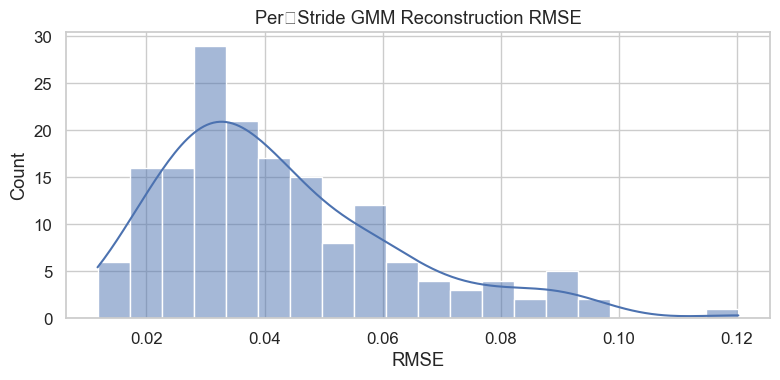


Generating KDE plots...


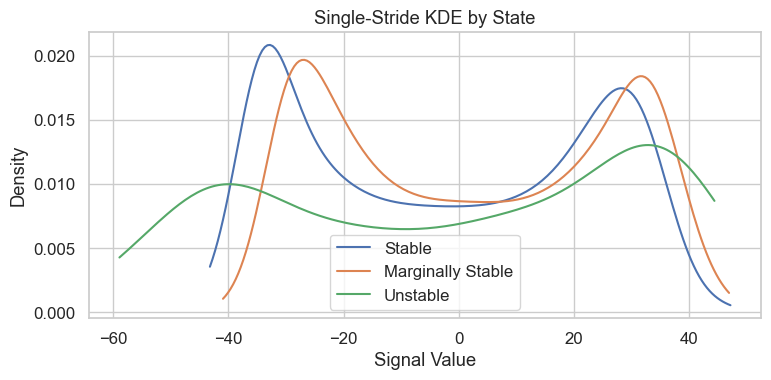

Generating faceted histograms...


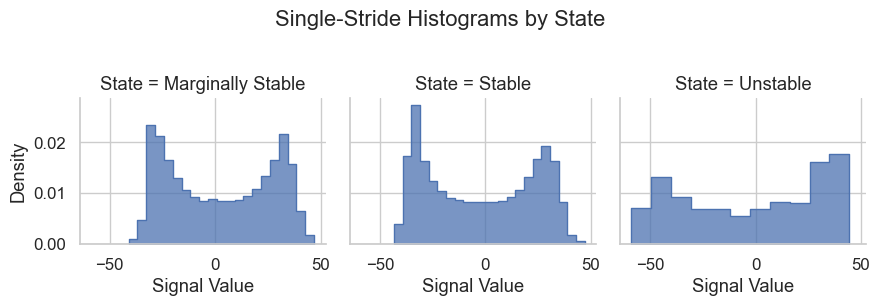

Generating per-stride histogram overlay...


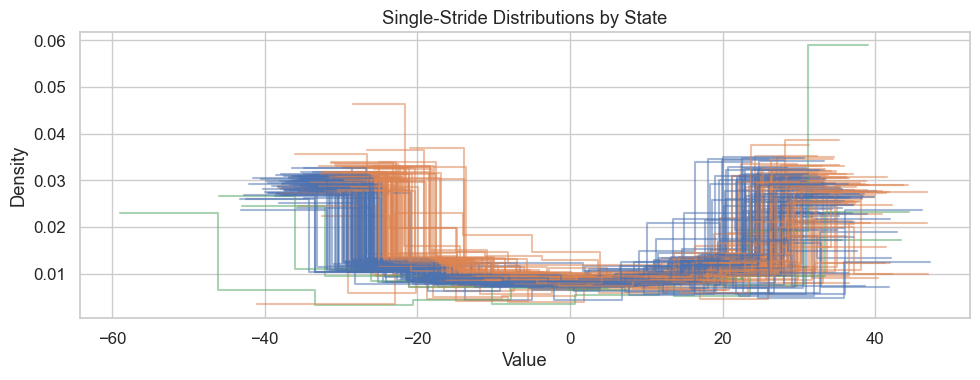

Generating time series with state overlay...


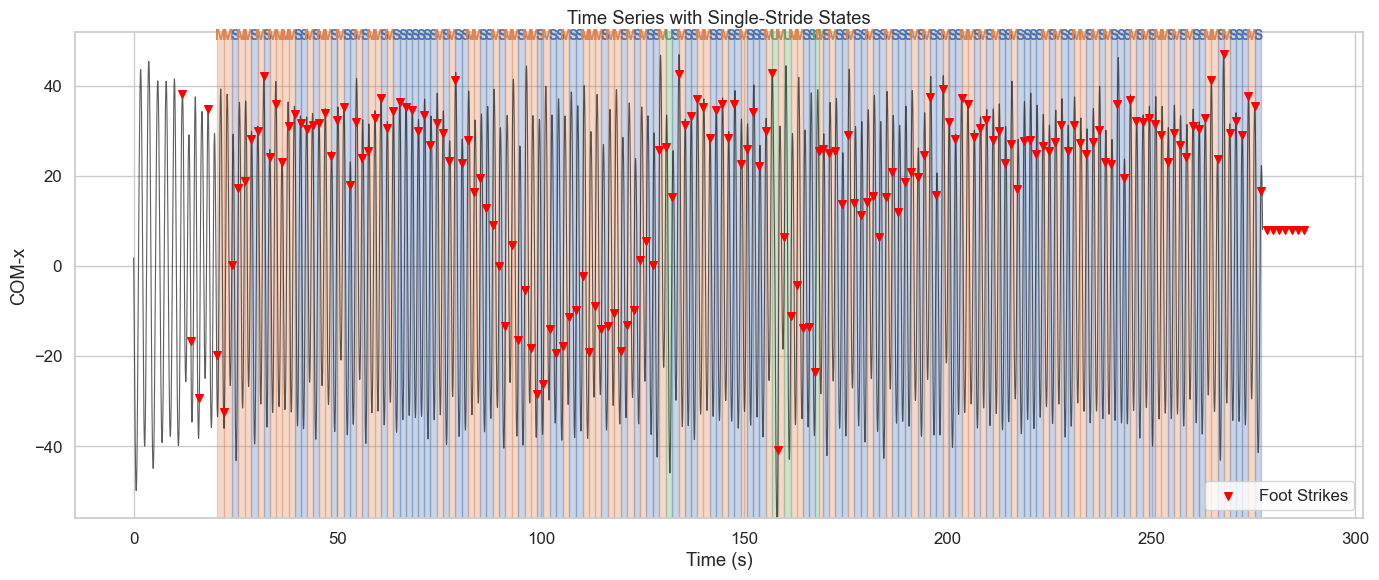


DISTRIBUTION-BASED MSM RESULTS

Total strides analyzed: 167
Average stride duration: 1.536 ± 0.083s

VALIDATION METRICS:
--------------------
GMM Reconstruction RMSE: 0.0470
  → Excellent GMM reconstruction quality
Clustering Silhouette Score: 0.219
  → Poor clustering - consider different parameters
Variance Explained by Clustering: 31.6%
  → Low variance explained - consider more states or different approach

TRANSITION ANALYSIS:
--------------------
Transition Matrix T:
[[0.409 0.58  0.011]
 [0.703 0.257 0.041]
 [0.25  0.75  0.   ]]

Stationary Distribution Π:
[0.535 0.441 0.024]

Mean Dwell Times τ (strides):
[1.692 1.345 1.   ]

STATE STATISTICS:
--------------------

Stable:
  Fraction of strides: 0.533
  Mean duration: 1.538s
  Duration std: 0.036s
  Histogram peak bin: 6
  Histogram entropy: 1.875

Marginally Stable:
  Fraction of strides: 0.443
  Mean duration: 1.544s
  Duration std: 0.082s
  Histogram peak bin: 2
  Histogram entropy: 1.807

Unstable:
  Fraction of strides: 0

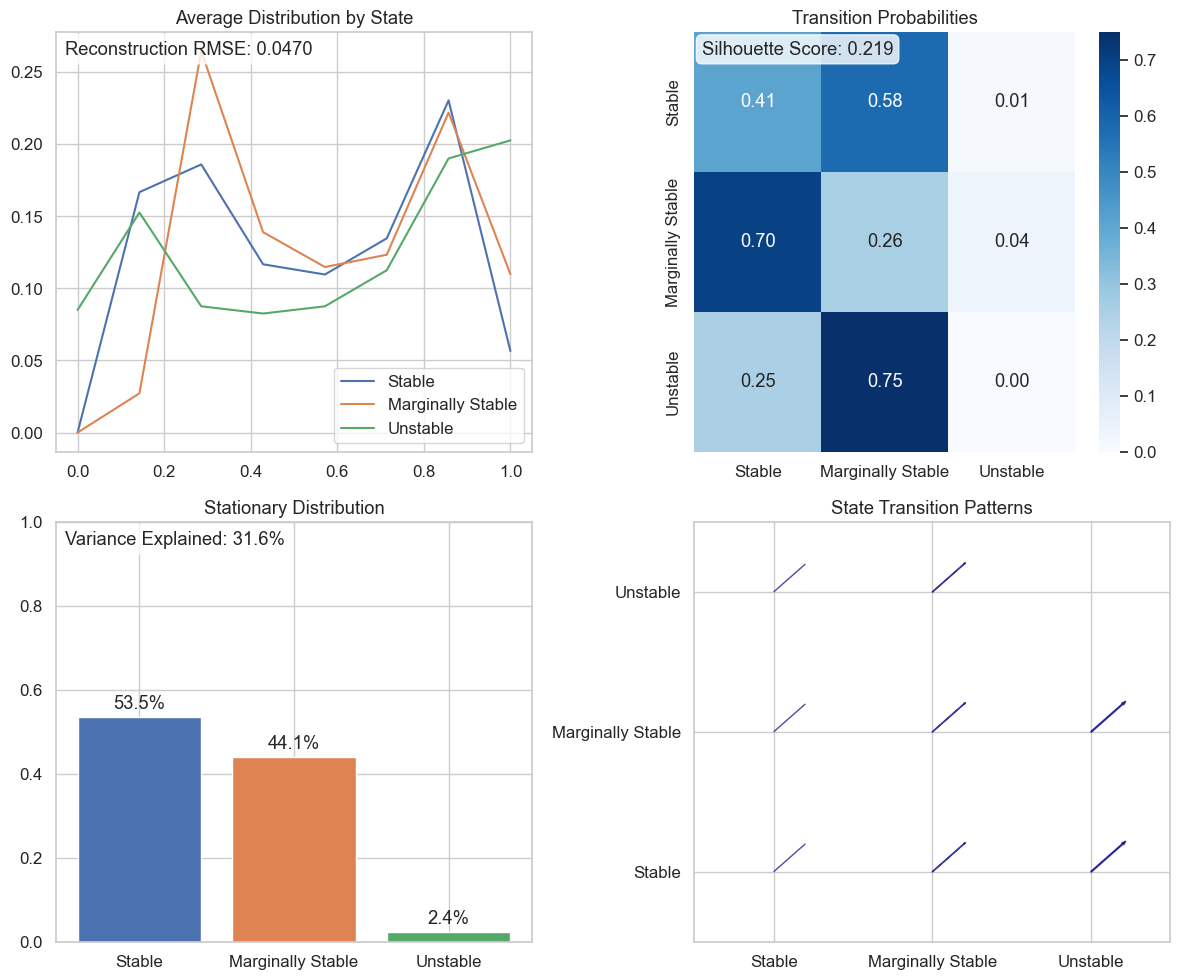


STATE SEQUENCE ANALYSIS

Found 112 state runs

Stable:
  Number of runs: 53
  Mean run length: 1.7 strides
  Max run length: 7 strides
  Min run length: 1 strides

Marginally Stable:
  Number of runs: 55
  Mean run length: 1.3 strides
  Max run length: 4 strides
  Min run length: 1 strides

Unstable:
  Number of runs: 4
  Mean run length: 1.0 strides
  Max run length: 1 strides
  Min run length: 1 strides

Generating validation plots...


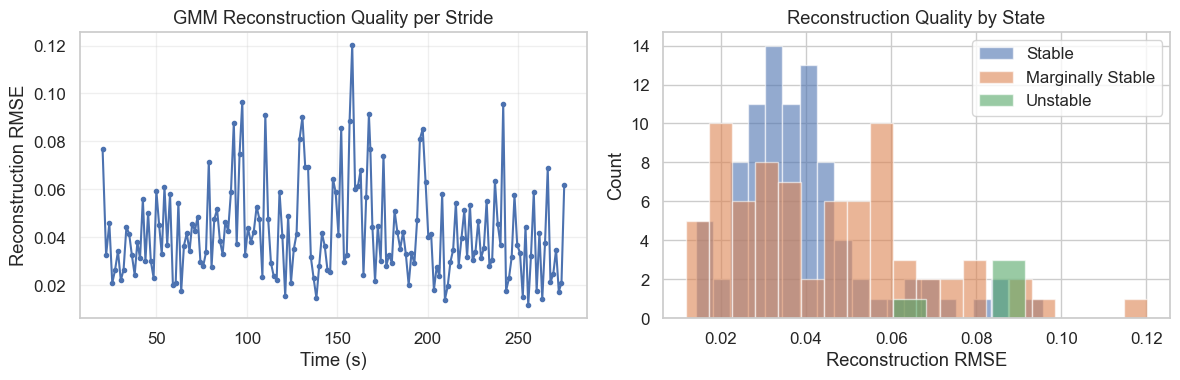


SUMMARY ASSESSMENT
Overall Quality Score: 2/6
Quality Notes:
  • Excellent GMM reconstruction
  • Poorly separated states
  • Low variance explained
  • Imbalanced state distribution

State Distribution: ['53.3%', '44.3%', '2.4%']
Dominant State: Stable


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
from preprocessing import preprocess_signal

def main():
    cwd = Path.cwd()
    marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.4" /"events.nc"
  
    fs = 100.0

    # 1) Load & preprocess COM-x
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs, poly_order=1,hp_cutoff=0.2, lp_cutoff=30.0)
    
    # Print signal characteristics for validation context
    print(f"Signal range: [{ts.min():.2f}, {ts.max():.2f}]")
    print(f"Signal std: {ts.std():.2f}")
    
    # 2) Extract foot strike events
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    
    avg_stride = np.mean(np.diff(strikes))
    win_samps = int(round(avg_stride * fs))
    print(f"Found {len(strikes)} foot strikes")
    print(f"Time range: {strikes[0]:.2f}s to {strikes[-1]:.2f}s")
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) Build & run DistributionMSM
    msm = DistributionMSM_Strides(
        patient_id="Y13", 
        n_states=3,
        n_bins=8, n_grid_points=100)
   
    
    # Fit the model
    msm.fit(ts, strikes, fs)
    states = df['state'].values
    msm.plot_gmm_reconstruction_error_distribution()
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}

    # 4) Overlaid kernel-density estimates (KDEs)
    print("\nGenerating KDE plots...")
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Gather all samples in strides of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(row.time*fs): int(row.time*fs + row.duration*fs)]
            for _, row in df.iloc[idxs].iterrows()
        ])
        if len(data) > 0:
            # Compute & plot KDE
            kde = gaussian_kde(data)
            xs = np.linspace(data.min(), data.max(), 200)
            plt.plot(xs, kde(xs), color=colors[st], label=label)
    
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Faceted histograms via Seaborn
    print("Generating faceted histograms...")
    # Build a "long" DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st = int(row.state)
        seg = ts[int(row.time * fs): int(row.time * fs) + int(row.duration * fs)]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value", stat="density", element="step", fill=True)
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()

    # 6) Per-stride histograms colored by state
    print("Generating per-stride histogram overlay...")
    plt.figure(figsize=(10, 4))
    for _, row in df.iterrows():
        st = int(row.state)
        start = int(row.time * fs)
        seg = ts[start: start + int(row.duration * fs)]
        sns.histplot(seg, bins=msm.n_bins, stat='density', element='step', 
                    fill=False, color=cmap[st], alpha=0.5)
    
    plt.title("Single-Stride Distributions by State")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # 7) Time series with S/M/U overlay
    print("Generating time series with state overlay...")
    letters = {0: "S", 1: "M", 2: "U"}
    times = np.arange(len(ts)) / fs
    plt.figure(figsize=(14, 6))
    plt.plot(times, ts, color='k', lw=0.8, alpha=0.7)
    
    for _, row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time + row.duration
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.3)
        plt.text((t0 + t1) / 2, ts.max() * 1.05, letters[st],
                ha='center', va='bottom', color=cmap[st], fontsize=10, fontweight='bold')
    
    # Mark foot strikes
    plt.scatter(strikes, np.interp(strikes, times, ts), 
               color='red', s=30, zorder=5, marker='v', label='Foot Strikes')
    
    plt.title("Time Series with Single-Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-x")
    plt.ylim(ts.min() * 0.95, ts.max() * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()
    summary_df = pd.DataFrame([summary])

    print("\n" + "="*50)
    print("DISTRIBUTION-BASED MSM RESULTS")
    print("="*50)
    print(f"\nTotal strides analyzed: {len(df)}")
    print(f"Average stride duration: {df['duration'].mean():.3f} ± {df['duration'].std():.3f}s")
    
    # Print validation metrics first
    print("\nVALIDATION METRICS:")
    print("-" * 20)
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            print(f"GMM Reconstruction RMSE: {rmse:.4f}")
            # Interpret relative to signal characteristics
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.01:
                print("  → Excellent GMM reconstruction quality")
            elif relative_rmse < 0.05:
                print("  → Good GMM reconstruction quality")
            elif relative_rmse < 0.1:
                print("  → Reasonable GMM reconstruction quality")
            else:
                print("  → Poor GMM reconstruction quality")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            print(f"Clustering Silhouette Score: {sil:.3f}")
            if sil > 0.7:
                print("  → Strong, well-separated clusters")
            elif sil > 0.5:
                print("  → Reasonable clustering quality")
            elif sil > 0.25:
                print("  → Weak clustering - states may overlap")
            else:
                print("  → Poor clustering - consider different parameters")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            print(f"Variance Explained by Clustering: {var_exp:.1%}")
            if var_exp > 0.7:
                print("  → Clustering captures most histogram variance")
            elif var_exp > 0.5:
                print("  → Clustering captures reasonable variance")
            else:
                print("  → Low variance explained - consider more states or different approach")

    print("\nTRANSITION ANALYSIS:")
    print("-" * 20)
    print("Transition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (strides):")
    print(np.round(tau, 3))
    
    print("\nSTATE STATISTICS:")
    print("-" * 20)
    for i in range(msm.n_states):
        state_data = df[df['state'] == i]
        print(f"\n{msm.state_labels[i]}:")
        print(f"  Fraction of strides: {len(state_data)/len(df):.3f}")
        print(f"  Mean duration: {state_data['duration'].mean():.3f}s")
        print(f"  Duration std: {state_data['duration'].std():.3f}s")
        
        # Show mean histogram characteristics
        cols = [c for c in state_data.columns if c.startswith('bin_')]
        mean_hist = state_data[cols].mean().values
        print(f"  Histogram peak bin: {np.argmax(mean_hist)}")
        print(f"  Histogram entropy: {-np.sum(mean_hist * np.log(mean_hist + 1e-10)):.3f}")

    # 9) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()

    # 10) State sequence analysis
    print("\n" + "="*50)
    print("STATE SEQUENCE ANALYSIS")
    print("="*50)
    
    # Find runs of consecutive states
    state_runs = []
    current_state = states[0]
    run_start = 0
    
    for i in range(1, len(states)):
        if states[i] != current_state:
            state_runs.append({
                'state': current_state,
                'start_idx': run_start,
                'end_idx': i-1,
                'length': i - run_start,
                'start_time': df.iloc[run_start]['time'],
                'end_time': df.iloc[i-1]['time']
            })
            current_state = states[i]
            run_start = i
    
    # Add final run
    state_runs.append({
        'state': current_state,
        'start_idx': run_start,
        'end_idx': len(states)-1,
        'length': len(states) - run_start,
        'start_time': df.iloc[run_start]['time'],
        'end_time': df.iloc[-1]['time']
    })
    
    # Analyze runs
    print(f"\nFound {len(state_runs)} state runs")
    for state in range(msm.n_states):
        runs = [r for r in state_runs if r['state'] == state]
        if runs:
            lengths = [r['length'] for r in runs]
            print(f"\n{msm.state_labels[state]}:")
            print(f"  Number of runs: {len(runs)}")
            print(f"  Mean run length: {np.mean(lengths):.1f} strides")
            print(f"  Max run length: {np.max(lengths)} strides")
            print(f"  Min run length: {np.min(lengths)} strides")

    # 11) Additional validation plots
    print("\nGenerating validation plots...")
    
    # Plot reconstruction quality per stride
    if 'gmm_reconstruction_rmse_per_stride' in msm.validation_metrics:
        plt.figure(figsize=(12, 4))
        per_stride_rmse = msm.validation_metrics['gmm_reconstruction_rmse_per_stride']
        
        plt.subplot(1, 2, 1)
        plt.plot(df['time'], per_stride_rmse, 'o-', markersize=3)
        plt.xlabel('Time (s)')
        plt.ylabel('Reconstruction RMSE')
        plt.title('GMM Reconstruction Quality per Stride')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        for state in range(msm.n_states):
            state_mask = df['state'] == state
            state_rmse = per_stride_rmse[state_mask]
            if len(state_rmse) == 0:
                continue

            # Choose bins = min(requested, unique‐value count) or use 'auto'
            unique_vals = np.unique(state_rmse)
            nbins = min(20, len(unique_vals)) if len(unique_vals)>1 else 1

            plt.hist(
                state_rmse,
                bins=nbins,                     # adapt to data
                alpha=0.6,
                label=msm.state_labels[state],
                color=colors[state],
            )
            plt.xlabel('Reconstruction RMSE')
        plt.ylabel('Count')
        plt.title('Reconstruction Quality by State')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Summary statistics
    print("\n" + "="*50)
    print("SUMMARY ASSESSMENT")
    print("="*50)
    
    # Overall quality assessment
    quality_score = 0
    quality_notes = []
    
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.05:
                quality_score += 2
                quality_notes.append("Excellent GMM reconstruction")
            elif relative_rmse < 0.1:
                quality_score += 1
                quality_notes.append("Good GMM reconstruction")
            else:
                quality_notes.append("Poor GMM reconstruction")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            if sil > 0.5:
                quality_score += 2
                quality_notes.append("Well-separated states")
            elif sil > 0.25:
                quality_score += 1
                quality_notes.append("Moderately separated states")
            else:
                quality_notes.append("Poorly separated states")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            if var_exp > 0.6:
                quality_score += 1
                quality_notes.append("Good variance explained")
            else:
                quality_notes.append("Low variance explained")
    
    # Check if states are balanced
    state_fractions = [np.mean(states == i) for i in range(msm.n_states)]
    if min(state_fractions) > 0.1:  # All states have at least 10% of data
        quality_score += 1
        quality_notes.append("Balanced state distribution")
    else:
        quality_notes.append("Imbalanced state distribution")
    
    print(f"Overall Quality Score: {quality_score}/6")
    print("Quality Notes:")
    for note in quality_notes:
        print(f"  • {note}")
    
    print(f"\nState Distribution: {[f'{f:.1%}' for f in state_fractions]}")
    print(f"Dominant State: {msm.state_labels[np.argmax(state_fractions)]}")
    
    return msm, summary,df

if __name__ == "__main__":
    model, metrics ,df= main()

### 14

Signal range: [-35.26, 34.41]
Signal std: 16.38
Found 201 foot strikes
Time range: 10.69s to 255.35s
Single-stride window = 122 samples (~1.22s)
No per‑stride GMM RMSE data.
Processing patient Y14 using stride-based histograms…
Created histograms from 200 valid strides
Average stride duration: 1.223s ± 0.025s
Identifying stability states via GMM…
GMM reconstruction RMSE: 0.0623
Clustering silhouette score: 0.164
Clustering quality: Poor clustering
Variance explained by clustering: 24.0%
Computing transition matrix…
Computing stationary distribution…

Stability metrics for Y14:
  frac_state_0: 0.495
  frac_state_1: 0.470
  frac_state_2: 0.035
  gmm_reconstruction_rmse: 0.062
  clustering_silhouette_score: 0.164
  variance_explained_by_clustering: 0.240

Validation Summary:
  GMM reconstruction quality: RMSE = 0.0623
  Clustering quality: Silhouette = 0.164
  Variance explained by clustering: 24.0%

Generating KDE plots...


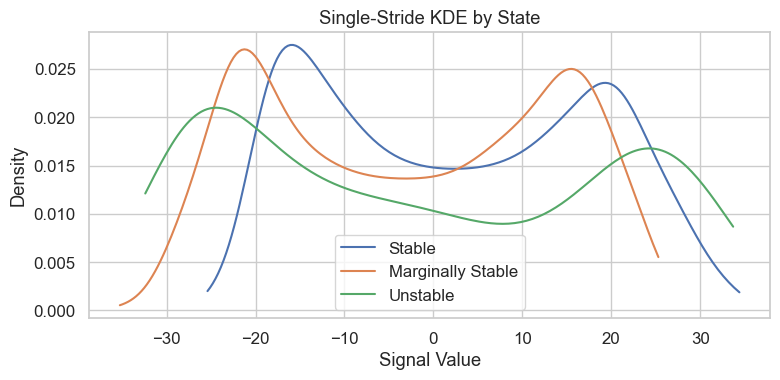

Generating faceted histograms...


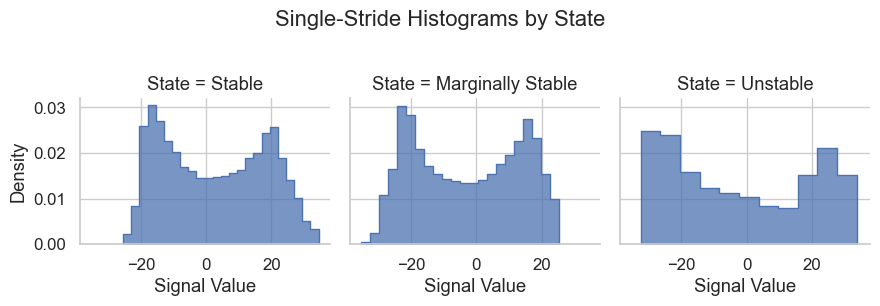

Generating per-stride histogram overlay...


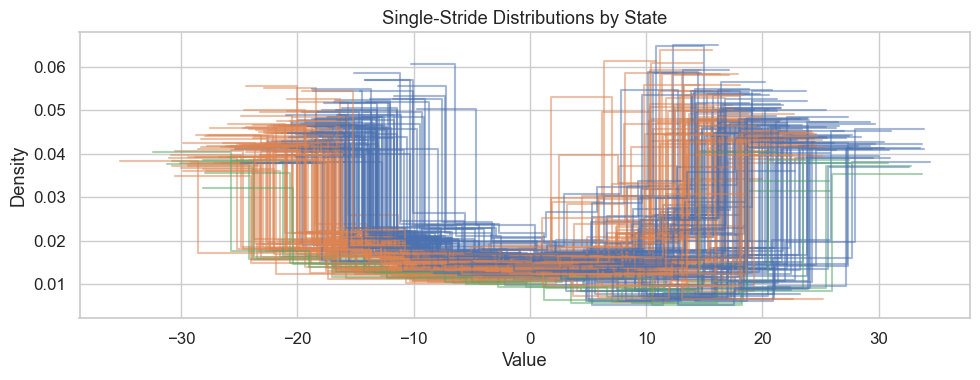

Generating time series with state overlay...


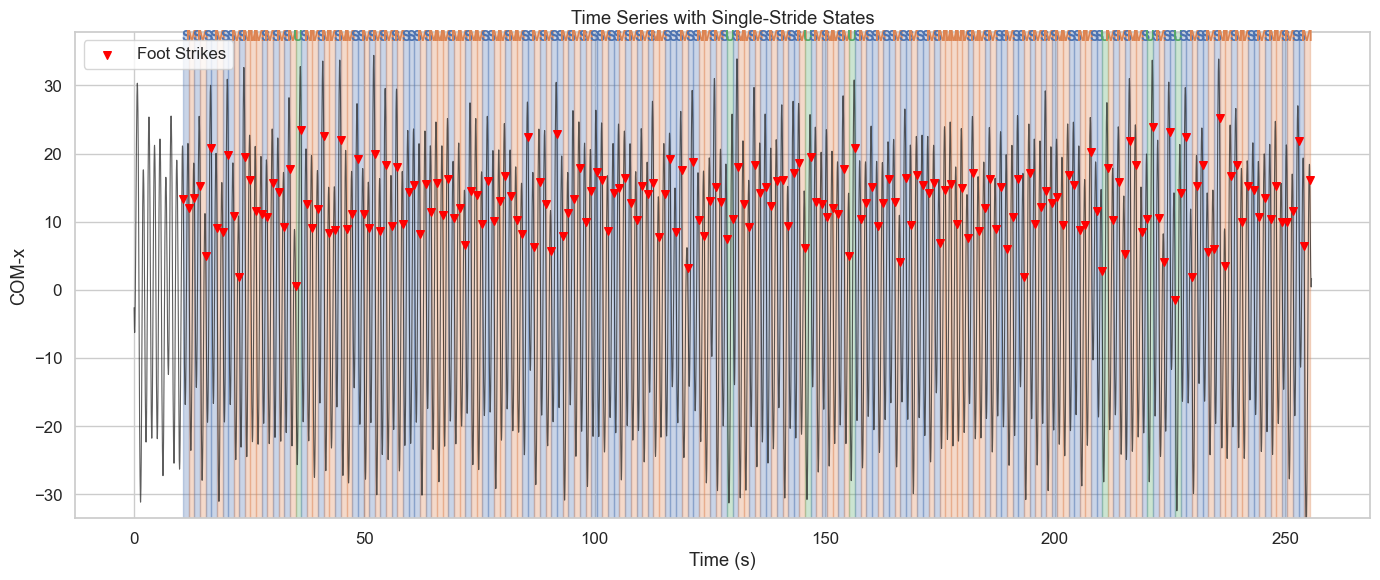


DISTRIBUTION-BASED MSM RESULTS

Total strides analyzed: 200
Average stride duration: 1.223 ± 0.025s

VALIDATION METRICS:
--------------------
GMM Reconstruction RMSE: 0.0623
  → Excellent GMM reconstruction quality
Clustering Silhouette Score: 0.164
  → Poor clustering - consider different parameters
Variance Explained by Clustering: 24.0%
  → Low variance explained - consider more states or different approach

TRANSITION ANALYSIS:
--------------------
Transition Matrix T:
[[0.283 0.677 0.04 ]
 [0.688 0.28  0.032]
 [0.857 0.143 0.   ]]

Stationary Distribution Π:
[0.494 0.471 0.035]

Mean Dwell Times τ (strides):
[1.394 1.388 1.   ]

STATE STATISTICS:
--------------------

Stable:
  Fraction of strides: 0.495
  Mean duration: 1.219s
  Duration std: 0.023s
  Histogram peak bin: 2
  Histogram entropy: 1.879

Marginally Stable:
  Fraction of strides: 0.470
  Mean duration: 1.227s
  Duration std: 0.024s
  Histogram peak bin: 1
  Histogram entropy: 1.865

Unstable:
  Fraction of strides: 0

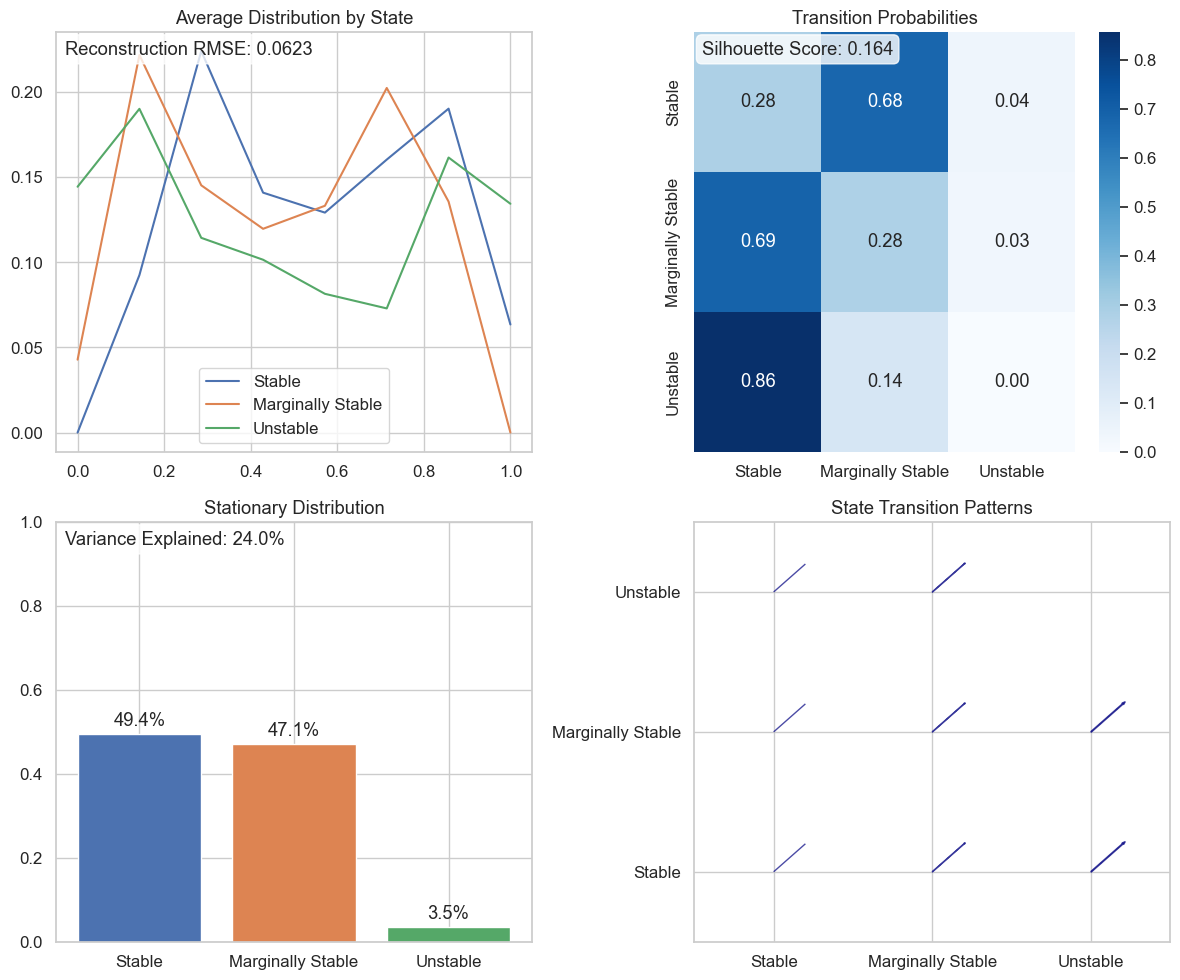


STATE SEQUENCE ANALYSIS

Found 146 state runs

Stable:
  Number of runs: 71
  Mean run length: 1.4 strides
  Max run length: 3 strides
  Min run length: 1 strides

Marginally Stable:
  Number of runs: 68
  Mean run length: 1.4 strides
  Max run length: 5 strides
  Min run length: 1 strides

Unstable:
  Number of runs: 7
  Mean run length: 1.0 strides
  Max run length: 1 strides
  Min run length: 1 strides

Generating validation plots...


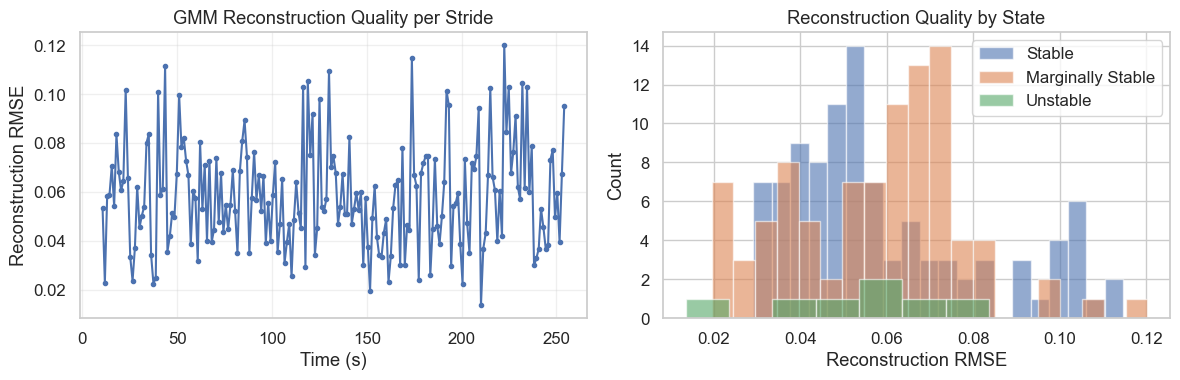


SUMMARY ASSESSMENT
Overall Quality Score: 2/6
Quality Notes:
  • Excellent GMM reconstruction
  • Poorly separated states
  • Low variance explained
  • Imbalanced state distribution

State Distribution: ['49.5%', '47.0%', '3.5%']
Dominant State: Stable


In [65]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
from preprocessing import preprocess_signal

def main():
    cwd = Path.cwd()
    marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_14"/"Pre.3" /"markers.nc"
    events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_14"/"Pre.4" /"events.nc"
    # marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "markers.nc"
    # events_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) Load & preprocess COM-x
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs, poly_order=1,hp_cutoff=0.2, lp_cutoff=30.0)
    
    # Print signal characteristics for validation context
    print(f"Signal range: [{ts.min():.2f}, {ts.max():.2f}]")
    print(f"Signal std: {ts.std():.2f}")
    
    # 2) Extract foot strike events
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    
    avg_stride = np.mean(np.diff(strikes))
    win_samps = int(round(avg_stride * fs))
    print(f"Found {len(strikes)} foot strikes")
    print(f"Time range: {strikes[0]:.2f}s to {strikes[-1]:.2f}s")
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) Build & run DistributionMSM
    msm = DistributionMSM_Strides(
        patient_id="Y14", 
        n_states=3,
        n_bins=8, n_grid_points=100
    )
    
    msm.plot_gmm_reconstruction_error_distribution()
    # Fit the model
    msm.fit(ts, strikes, fs)
    df = msm.metrics_history
    states = df['state'].values
    
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}

    # 4) Overlaid kernel-density estimates (KDEs)
    print("\nGenerating KDE plots...")
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Gather all samples in strides of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(row.time*fs): int(row.time*fs + row.duration*fs)]
            for _, row in df.iloc[idxs].iterrows()
        ])
        if len(data) > 0:
            # Compute & plot KDE
            kde = gaussian_kde(data)
            xs = np.linspace(data.min(), data.max(), 200)
            plt.plot(xs, kde(xs), color=colors[st], label=label)
    
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Faceted histograms via Seaborn
    print("Generating faceted histograms...")
    # Build a "long" DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st = int(row.state)
        seg = ts[int(row.time * fs): int(row.time * fs) + int(row.duration * fs)]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value", stat="density", element="step", fill=True)
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()

    # 6) Per-stride histograms colored by state
    print("Generating per-stride histogram overlay...")
    plt.figure(figsize=(10, 4))
    for _, row in df.iterrows():
        st = int(row.state)
        start = int(row.time * fs)
        seg = ts[start: start + int(row.duration * fs)]
        sns.histplot(seg, bins=msm.n_bins, stat='density', element='step', 
                    fill=False, color=cmap[st], alpha=0.5)
    
    plt.title("Single-Stride Distributions by State")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # 7) Time series with S/M/U overlay
    print("Generating time series with state overlay...")
    letters = {0: "S", 1: "M", 2: "U"}
    times = np.arange(len(ts)) / fs
    plt.figure(figsize=(14, 6))
    plt.plot(times, ts, color='k', lw=0.8, alpha=0.7)
    
    for _, row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time + row.duration
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.3)
        plt.text((t0 + t1) / 2, ts.max() * 1.05, letters[st],
                ha='center', va='bottom', color=cmap[st], fontsize=10, fontweight='bold')
    
    # Mark foot strikes
    plt.scatter(strikes, np.interp(strikes, times, ts), 
               color='red', s=30, zorder=5, marker='v', label='Foot Strikes')
    
    plt.title("Time Series with Single-Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-x")
    plt.ylim(ts.min() * 0.95, ts.max() * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()
    summary_df = pd.DataFrame([summary])

    print("\n" + "="*50)
    print("DISTRIBUTION-BASED MSM RESULTS")
    print("="*50)
    print(f"\nTotal strides analyzed: {len(df)}")
    print(f"Average stride duration: {df['duration'].mean():.3f} ± {df['duration'].std():.3f}s")
    
    # Print validation metrics first
    print("\nVALIDATION METRICS:")
    print("-" * 20)
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            print(f"GMM Reconstruction RMSE: {rmse:.4f}")
            # Interpret relative to signal characteristics
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.01:
                print("  → Excellent GMM reconstruction quality")
            elif relative_rmse < 0.05:
                print("  → Good GMM reconstruction quality")
            elif relative_rmse < 0.1:
                print("  → Reasonable GMM reconstruction quality")
            else:
                print("  → Poor GMM reconstruction quality")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            print(f"Clustering Silhouette Score: {sil:.3f}")
            if sil > 0.7:
                print("  → Strong, well-separated clusters")
            elif sil > 0.5:
                print("  → Reasonable clustering quality")
            elif sil > 0.25:
                print("  → Weak clustering - states may overlap")
            else:
                print("  → Poor clustering - consider different parameters")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            print(f"Variance Explained by Clustering: {var_exp:.1%}")
            if var_exp > 0.7:
                print("  → Clustering captures most histogram variance")
            elif var_exp > 0.5:
                print("  → Clustering captures reasonable variance")
            else:
                print("  → Low variance explained - consider more states or different approach")

    print("\nTRANSITION ANALYSIS:")
    print("-" * 20)
    print("Transition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (strides):")
    print(np.round(tau, 3))
    
    print("\nSTATE STATISTICS:")
    print("-" * 20)
    for i in range(msm.n_states):
        state_data = df[df['state'] == i]
        print(f"\n{msm.state_labels[i]}:")
        print(f"  Fraction of strides: {len(state_data)/len(df):.3f}")
        print(f"  Mean duration: {state_data['duration'].mean():.3f}s")
        print(f"  Duration std: {state_data['duration'].std():.3f}s")
        
        # Show mean histogram characteristics
        cols = [c for c in state_data.columns if c.startswith('bin_')]
        mean_hist = state_data[cols].mean().values
        print(f"  Histogram peak bin: {np.argmax(mean_hist)}")
        print(f"  Histogram entropy: {-np.sum(mean_hist * np.log(mean_hist + 1e-10)):.3f}")

    # 9) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()

    # 10) State sequence analysis
    print("\n" + "="*50)
    print("STATE SEQUENCE ANALYSIS")
    print("="*50)
    
    # Find runs of consecutive states
    state_runs = []
    current_state = states[0]
    run_start = 0
    
    for i in range(1, len(states)):
        if states[i] != current_state:
            state_runs.append({
                'state': current_state,
                'start_idx': run_start,
                'end_idx': i-1,
                'length': i - run_start,
                'start_time': df.iloc[run_start]['time'],
                'end_time': df.iloc[i-1]['time']
            })
            current_state = states[i]
            run_start = i
    
    # Add final run
    state_runs.append({
        'state': current_state,
        'start_idx': run_start,
        'end_idx': len(states)-1,
        'length': len(states) - run_start,
        'start_time': df.iloc[run_start]['time'],
        'end_time': df.iloc[-1]['time']
    })
    
    # Analyze runs
    print(f"\nFound {len(state_runs)} state runs")
    for state in range(msm.n_states):
        runs = [r for r in state_runs if r['state'] == state]
        if runs:
            lengths = [r['length'] for r in runs]
            print(f"\n{msm.state_labels[state]}:")
            print(f"  Number of runs: {len(runs)}")
            print(f"  Mean run length: {np.mean(lengths):.1f} strides")
            print(f"  Max run length: {np.max(lengths)} strides")
            print(f"  Min run length: {np.min(lengths)} strides")

    # 11) Additional validation plots
    print("\nGenerating validation plots...")
    
    # Plot reconstruction quality per stride
    if 'gmm_reconstruction_rmse_per_stride' in msm.validation_metrics:
        plt.figure(figsize=(12, 4))
        per_stride_rmse = msm.validation_metrics['gmm_reconstruction_rmse_per_stride']
        
        plt.subplot(1, 2, 1)
        plt.plot(df['time'], per_stride_rmse, 'o-', markersize=3)
        plt.xlabel('Time (s)')
        plt.ylabel('Reconstruction RMSE')
        plt.title('GMM Reconstruction Quality per Stride')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        for state in range(msm.n_states):
            state_mask = df['state'] == state
            state_rmse = per_stride_rmse[state_mask]
            if len(state_rmse) == 0:
                continue

            # Choose bins = min(requested, unique‐value count) or use 'auto'
            unique_vals = np.unique(state_rmse)
            nbins = min(20, len(unique_vals)) if len(unique_vals)>1 else 1

            plt.hist(
                state_rmse,
                bins=nbins,                     # adapt to data
                alpha=0.6,
                label=msm.state_labels[state],
                color=colors[state],
            )
            plt.xlabel('Reconstruction RMSE')
        plt.ylabel('Count')
        plt.title('Reconstruction Quality by State')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Summary statistics
    print("\n" + "="*50)
    print("SUMMARY ASSESSMENT")
    print("="*50)
    
    # Overall quality assessment
    quality_score = 0
    quality_notes = []
    
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.05:
                quality_score += 2
                quality_notes.append("Excellent GMM reconstruction")
            elif relative_rmse < 0.1:
                quality_score += 1
                quality_notes.append("Good GMM reconstruction")
            else:
                quality_notes.append("Poor GMM reconstruction")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            if sil > 0.5:
                quality_score += 2
                quality_notes.append("Well-separated states")
            elif sil > 0.25:
                quality_score += 1
                quality_notes.append("Moderately separated states")
            else:
                quality_notes.append("Poorly separated states")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            if var_exp > 0.6:
                quality_score += 1
                quality_notes.append("Good variance explained")
            else:
                quality_notes.append("Low variance explained")
    
    # Check if states are balanced
    state_fractions = [np.mean(states == i) for i in range(msm.n_states)]
    if min(state_fractions) > 0.1:  # All states have at least 10% of data
        quality_score += 1
        quality_notes.append("Balanced state distribution")
    else:
        quality_notes.append("Imbalanced state distribution")
    
    print(f"Overall Quality Score: {quality_score}/6")
    print("Quality Notes:")
    for note in quality_notes:
        print(f"  • {note}")
    
    print(f"\nState Distribution: {[f'{f:.1%}' for f in state_fractions]}")
    print(f"Dominant State: {msm.state_labels[np.argmax(state_fractions)]}")
    
    return msm, summary, summary_df

if __name__ == "__main__":
    model, metrics ,df= main()

## Model Fit - CGA 

### 04 - PWS

Signal range: [-45.56, 40.51]
Signal std: 15.31
Found 57 foot strikes
Time range: 5.82s to 69.33s
Single-stride window = 113 samples (~1.13s)
No per‑stride GMM RMSE data.
Processing patient 04_PWS using stride-based histograms…
Created histograms from 56 valid strides
Average stride duration: 1.134s ± 0.022s
Identifying stability states via GMM…
GMM reconstruction RMSE: 0.0769
Clustering silhouette score: 0.264
Clustering quality: Weak clustering
Variance explained by clustering: 31.7%
Computing transition matrix…
Computing stationary distribution…

Stability metrics for 04_PWS:
  frac_state_0: 0.679
  frac_state_1: 0.250
  frac_state_2: 0.071
  gmm_reconstruction_rmse: 0.077
  clustering_silhouette_score: 0.264
  variance_explained_by_clustering: 0.317

Validation Summary:
  GMM reconstruction quality: RMSE = 0.0769
  Clustering quality: Silhouette = 0.264
  Variance explained by clustering: 31.7%

Generating KDE plots...


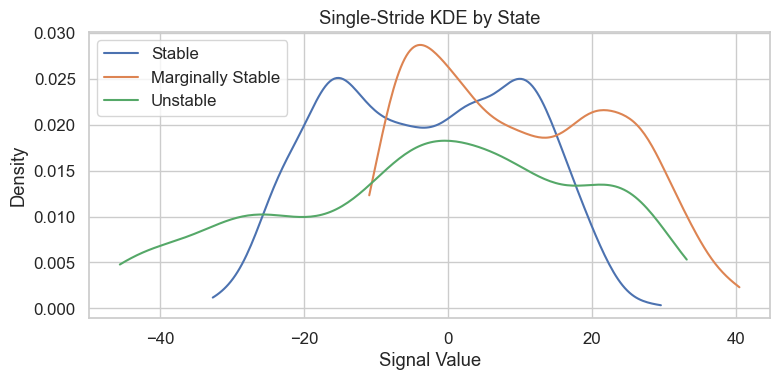

Generating faceted histograms...


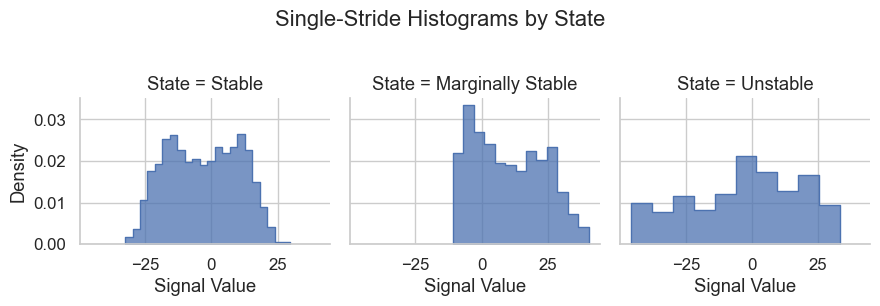

Generating per-stride histogram overlay...


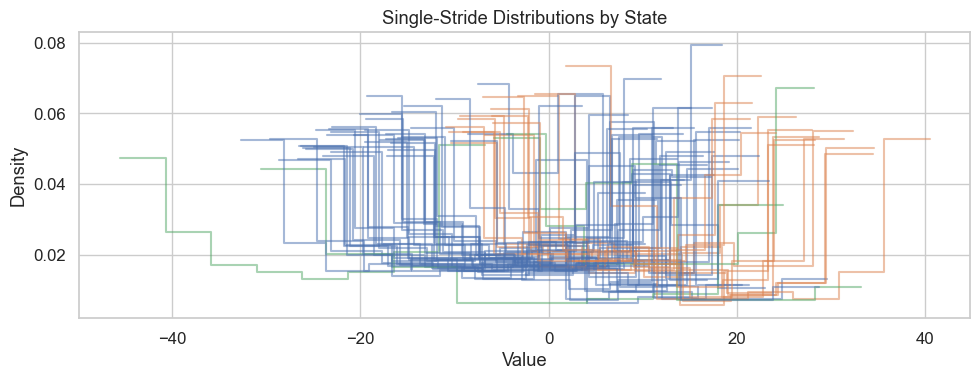

Generating time series with state overlay...


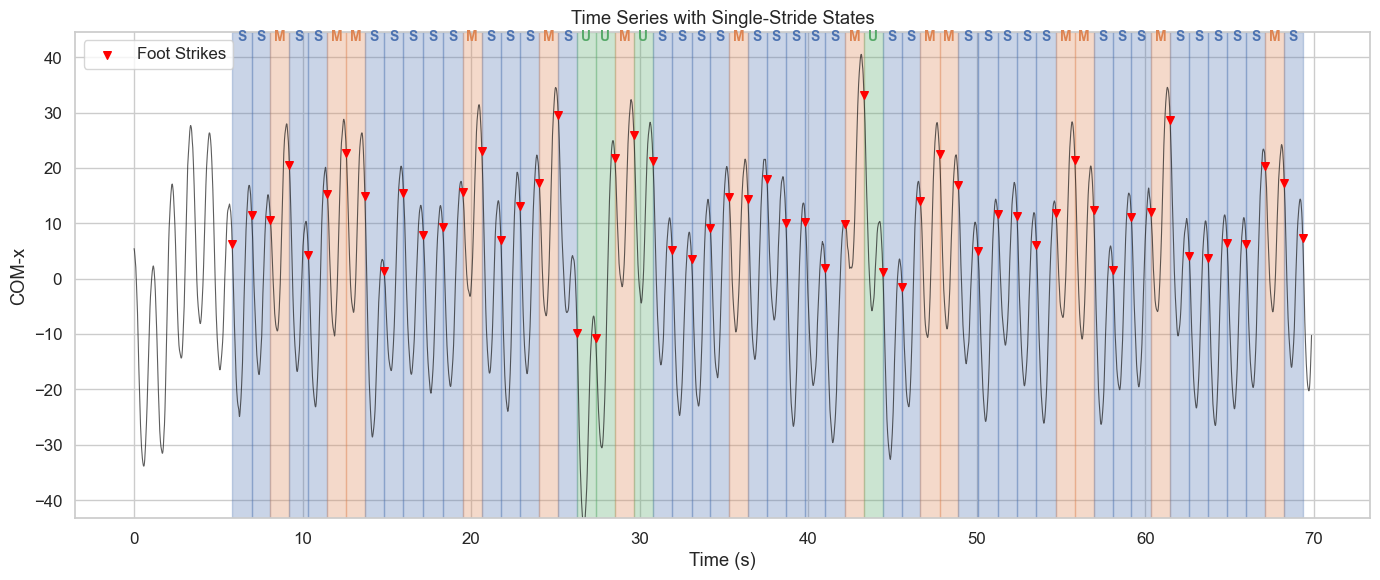


DISTRIBUTION-BASED MSM RESULTS

Total strides analyzed: 56
Average stride duration: 1.134 ± 0.022s

VALIDATION METRICS:
--------------------
GMM Reconstruction RMSE: 0.0769
  → Excellent GMM reconstruction quality
Clustering Silhouette Score: 0.264
  → Weak clustering - states may overlap
Variance Explained by Clustering: 31.7%
  → Low variance explained - consider more states or different approach

TRANSITION ANALYSIS:
--------------------
Transition Matrix T:
[[0.703 0.27  0.027]
 [0.643 0.214 0.143]
 [0.5   0.25  0.25 ]]

Stationary Distribution Π:
[0.673 0.255 0.073]

Mean Dwell Times τ (strides):
[3.364 1.273 1.333]

STATE STATISTICS:
--------------------

Stable:
  Fraction of strides: 0.679
  Mean duration: 1.140s
  Duration std: 0.023s
  Histogram peak bin: 2
  Histogram entropy: 1.607

Marginally Stable:
  Fraction of strides: 0.250
  Mean duration: 1.121s
  Duration std: 0.011s
  Histogram peak bin: 4
  Histogram entropy: 1.551

Unstable:
  Fraction of strides: 0.071
  Mean 

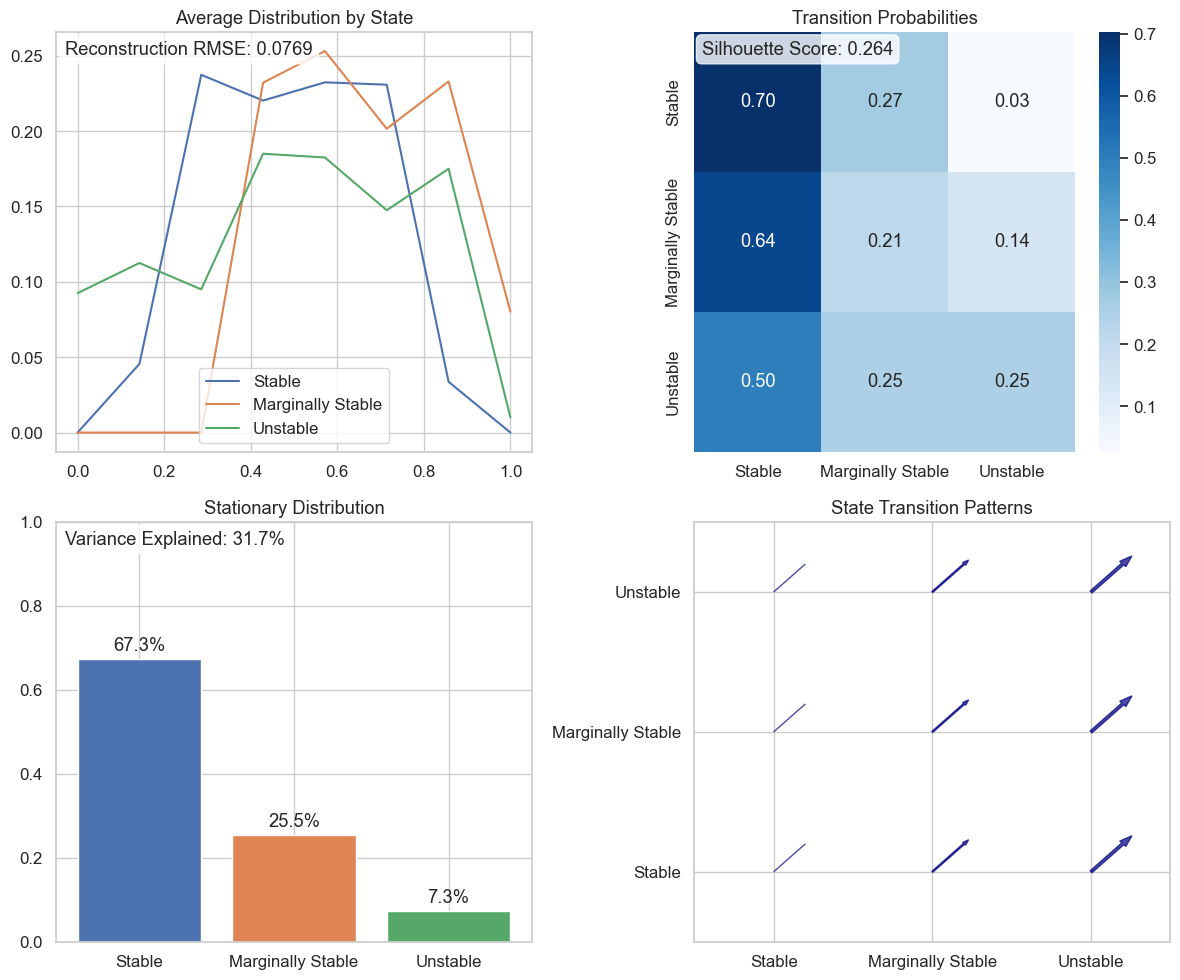


STATE SEQUENCE ANALYSIS

Found 26 state runs

Stable:
  Number of runs: 12
  Mean run length: 3.2 strides
  Max run length: 5 strides
  Min run length: 1 strides

Marginally Stable:
  Number of runs: 11
  Mean run length: 1.3 strides
  Max run length: 2 strides
  Min run length: 1 strides

Unstable:
  Number of runs: 3
  Mean run length: 1.3 strides
  Max run length: 2 strides
  Min run length: 1 strides

Generating validation plots...


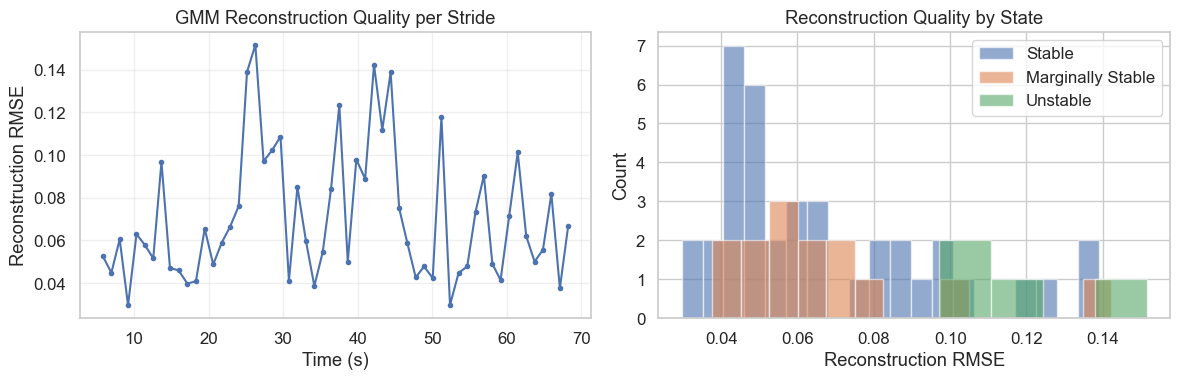


SUMMARY ASSESSMENT
Overall Quality Score: 3/6
Quality Notes:
  • Excellent GMM reconstruction
  • Moderately separated states
  • Low variance explained
  • Imbalanced state distribution

State Distribution: ['67.9%', '25.0%', '7.1%']
Dominant State: Stable


In [66]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
from preprocessing import preprocess_signal

def main():
    cwd = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.4" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "markers.nc"
    events_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) Load & preprocess COM-x
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs, poly_order=1,hp_cutoff=0.1, lp_cutoff=30.0)
    
    # Print signal characteristics for validation context
    print(f"Signal range: [{ts.min():.2f}, {ts.max():.2f}]")
    print(f"Signal std: {ts.std():.2f}")
    
    # 2) Extract foot strike events
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=5")["time"].values)
    
    avg_stride = np.mean(np.diff(strikes))
    win_samps = int(round(avg_stride * fs))
    print(f"Found {len(strikes)} foot strikes")
    print(f"Time range: {strikes[0]:.2f}s to {strikes[-1]:.2f}s")
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) Build & run DistributionMSM
    msm = DistributionMSM_Strides(
        patient_id="04_PWS", 
        n_states=3,
        n_bins=8, n_grid_points=100
    )
    
    msm.plot_gmm_reconstruction_error_distribution()
    # Fit the model
    msm.fit(ts, strikes, fs)
    df = msm.metrics_history
    states = df['state'].values
    
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}

    # 4) Overlaid kernel-density estimates (KDEs)
    print("\nGenerating KDE plots...")
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Gather all samples in strides of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(row.time*fs): int(row.time*fs + row.duration*fs)]
            for _, row in df.iloc[idxs].iterrows()
        ])
        if len(data) > 0:
            # Compute & plot KDE
            kde = gaussian_kde(data)
            xs = np.linspace(data.min(), data.max(), 200)
            plt.plot(xs, kde(xs), color=colors[st], label=label)
    
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Faceted histograms via Seaborn
    print("Generating faceted histograms...")
    # Build a "long" DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st = int(row.state)
        seg = ts[int(row.time * fs): int(row.time * fs) + int(row.duration * fs)]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value", stat="density", element="step", fill=True)
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()

    # 6) Per-stride histograms colored by state
    print("Generating per-stride histogram overlay...")
    plt.figure(figsize=(10, 4))
    for _, row in df.iterrows():
        st = int(row.state)
        start = int(row.time * fs)
        seg = ts[start: start + int(row.duration * fs)]
        sns.histplot(seg, bins=msm.n_bins, stat='density', element='step', 
                    fill=False, color=cmap[st], alpha=0.5)
    
    plt.title("Single-Stride Distributions by State")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # 7) Time series with S/M/U overlay
    print("Generating time series with state overlay...")
    letters = {0: "S", 1: "M", 2: "U"}
    times = np.arange(len(ts)) / fs
    plt.figure(figsize=(14, 6))
    plt.plot(times, ts, color='k', lw=0.8, alpha=0.7)
    
    for _, row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time + row.duration
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.3)
        plt.text((t0 + t1) / 2, ts.max() * 1.05, letters[st],
                ha='center', va='bottom', color=cmap[st], fontsize=10, fontweight='bold')
    
    # Mark foot strikes
    plt.scatter(strikes, np.interp(strikes, times, ts), 
               color='red', s=30, zorder=5, marker='v', label='Foot Strikes')
    
    plt.title("Time Series with Single-Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-x")
    plt.ylim(ts.min() * 0.95, ts.max() * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    print("\n" + "="*50)
    print("DISTRIBUTION-BASED MSM RESULTS")
    print("="*50)
    print(f"\nTotal strides analyzed: {len(df)}")
    print(f"Average stride duration: {df['duration'].mean():.3f} ± {df['duration'].std():.3f}s")
    
    # Print validation metrics first
    print("\nVALIDATION METRICS:")
    print("-" * 20)
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            print(f"GMM Reconstruction RMSE: {rmse:.4f}")
            # Interpret relative to signal characteristics
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.01:
                print("  → Excellent GMM reconstruction quality")
            elif relative_rmse < 0.05:
                print("  → Good GMM reconstruction quality")
            elif relative_rmse < 0.1:
                print("  → Reasonable GMM reconstruction quality")
            else:
                print("  → Poor GMM reconstruction quality")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            print(f"Clustering Silhouette Score: {sil:.3f}")
            if sil > 0.7:
                print("  → Strong, well-separated clusters")
            elif sil > 0.5:
                print("  → Reasonable clustering quality")
            elif sil > 0.25:
                print("  → Weak clustering - states may overlap")
            else:
                print("  → Poor clustering - consider different parameters")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            print(f"Variance Explained by Clustering: {var_exp:.1%}")
            if var_exp > 0.7:
                print("  → Clustering captures most histogram variance")
            elif var_exp > 0.5:
                print("  → Clustering captures reasonable variance")
            else:
                print("  → Low variance explained - consider more states or different approach")

    print("\nTRANSITION ANALYSIS:")
    print("-" * 20)
    print("Transition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (strides):")
    print(np.round(tau, 3))
    
    print("\nSTATE STATISTICS:")
    print("-" * 20)
    for i in range(msm.n_states):
        state_data = df[df['state'] == i]
        print(f"\n{msm.state_labels[i]}:")
        print(f"  Fraction of strides: {len(state_data)/len(df):.3f}")
        print(f"  Mean duration: {state_data['duration'].mean():.3f}s")
        print(f"  Duration std: {state_data['duration'].std():.3f}s")
        
        # Show mean histogram characteristics
        cols = [c for c in state_data.columns if c.startswith('bin_')]
        mean_hist = state_data[cols].mean().values
        print(f"  Histogram peak bin: {np.argmax(mean_hist)}")
        print(f"  Histogram entropy: {-np.sum(mean_hist * np.log(mean_hist + 1e-10)):.3f}")

    # 9) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()

    # 10) State sequence analysis
    print("\n" + "="*50)
    print("STATE SEQUENCE ANALYSIS")
    print("="*50)
    
    # Find runs of consecutive states
    state_runs = []
    current_state = states[0]
    run_start = 0
    
    for i in range(1, len(states)):
        if states[i] != current_state:
            state_runs.append({
                'state': current_state,
                'start_idx': run_start,
                'end_idx': i-1,
                'length': i - run_start,
                'start_time': df.iloc[run_start]['time'],
                'end_time': df.iloc[i-1]['time']
            })
            current_state = states[i]
            run_start = i
    
    # Add final run
    state_runs.append({
        'state': current_state,
        'start_idx': run_start,
        'end_idx': len(states)-1,
        'length': len(states) - run_start,
        'start_time': df.iloc[run_start]['time'],
        'end_time': df.iloc[-1]['time']
    })
    
    # Analyze runs
    print(f"\nFound {len(state_runs)} state runs")
    for state in range(msm.n_states):
        runs = [r for r in state_runs if r['state'] == state]
        if runs:
            lengths = [r['length'] for r in runs]
            print(f"\n{msm.state_labels[state]}:")
            print(f"  Number of runs: {len(runs)}")
            print(f"  Mean run length: {np.mean(lengths):.1f} strides")
            print(f"  Max run length: {np.max(lengths)} strides")
            print(f"  Min run length: {np.min(lengths)} strides")

    # 11) Additional validation plots
    print("\nGenerating validation plots...")
    
    # Plot reconstruction quality per stride
    if 'gmm_reconstruction_rmse_per_stride' in msm.validation_metrics:
        plt.figure(figsize=(12, 4))
        per_stride_rmse = msm.validation_metrics['gmm_reconstruction_rmse_per_stride']
        
        plt.subplot(1, 2, 1)
        plt.plot(df['time'], per_stride_rmse, 'o-', markersize=3)
        plt.xlabel('Time (s)')
        plt.ylabel('Reconstruction RMSE')
        plt.title('GMM Reconstruction Quality per Stride')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        for state in range(msm.n_states):
            state_mask = df['state'] == state
            state_rmse = per_stride_rmse[state_mask]
            if len(state_rmse) == 0:
                continue

            # Choose bins = min(requested, unique‐value count) or use 'auto'
            unique_vals = np.unique(state_rmse)
            nbins = min(20, len(unique_vals)) if len(unique_vals)>1 else 1

            plt.hist(
                state_rmse,
                bins=nbins,                     # adapt to data
                alpha=0.6,
                label=msm.state_labels[state],
                color=colors[state],
            )
            plt.xlabel('Reconstruction RMSE')
        plt.ylabel('Count')
        plt.title('Reconstruction Quality by State')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Summary statistics
    print("\n" + "="*50)
    print("SUMMARY ASSESSMENT")
    print("="*50)
    
    # Overall quality assessment
    quality_score = 0
    quality_notes = []
    
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.05:
                quality_score += 2
                quality_notes.append("Excellent GMM reconstruction")
            elif relative_rmse < 0.1:
                quality_score += 1
                quality_notes.append("Good GMM reconstruction")
            else:
                quality_notes.append("Poor GMM reconstruction")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            if sil > 0.5:
                quality_score += 2
                quality_notes.append("Well-separated states")
            elif sil > 0.25:
                quality_score += 1
                quality_notes.append("Moderately separated states")
            else:
                quality_notes.append("Poorly separated states")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            if var_exp > 0.6:
                quality_score += 1
                quality_notes.append("Good variance explained")
            else:
                quality_notes.append("Low variance explained")
    
    # Check if states are balanced
    state_fractions = [np.mean(states == i) for i in range(msm.n_states)]
    if min(state_fractions) > 0.1:  # All states have at least 10% of data
        quality_score += 1
        quality_notes.append("Balanced state distribution")
    else:
        quality_notes.append("Imbalanced state distribution")
    
    print(f"Overall Quality Score: {quality_score}/6")
    print("Quality Notes:")
    for note in quality_notes:
        print(f"  • {note}")
    
    print(f"\nState Distribution: {[f'{f:.1%}' for f in state_fractions]}")
    print(f"Dominant State: {msm.state_labels[np.argmax(state_fractions)]}")
    
    return msm, summary

if __name__ == "__main__":
    model, metrics = main()

### 04 - SWS

Signal range: [-46.26, 40.04]
Signal std: 20.60
Found 55 foot strikes
Time range: 6.12s to 84.35s
Single-stride window = 145 samples (~1.45s)
No per‑stride GMM RMSE data.
Processing patient 04_SWS using stride-based histograms…
Created histograms from 54 valid strides
Average stride duration: 1.449s ± 0.094s
Identifying stability states via GMM…
GMM reconstruction RMSE: 0.0577
Clustering silhouette score: 0.188
Clustering quality: Poor clustering
Variance explained by clustering: 44.0%
Computing transition matrix…
Computing stationary distribution…

Stability metrics for 04_SWS:
  frac_state_0: 0.444
  frac_state_1: 0.130
  frac_state_2: 0.426
  gmm_reconstruction_rmse: 0.058
  clustering_silhouette_score: 0.188
  variance_explained_by_clustering: 0.440

Validation Summary:
  GMM reconstruction quality: RMSE = 0.0577
  Clustering quality: Silhouette = 0.188
  Variance explained by clustering: 44.0%

Generating KDE plots...


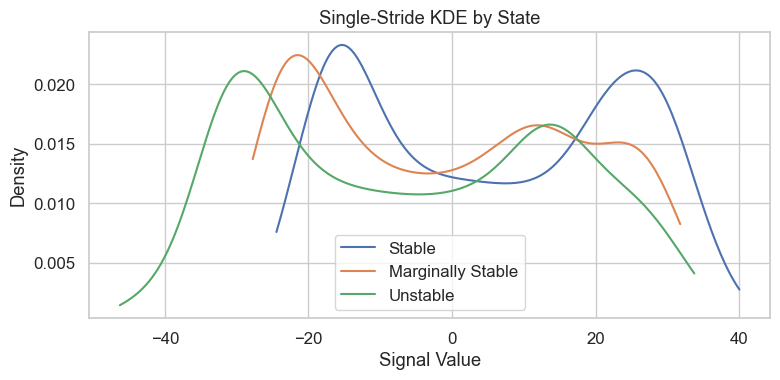

Generating faceted histograms...


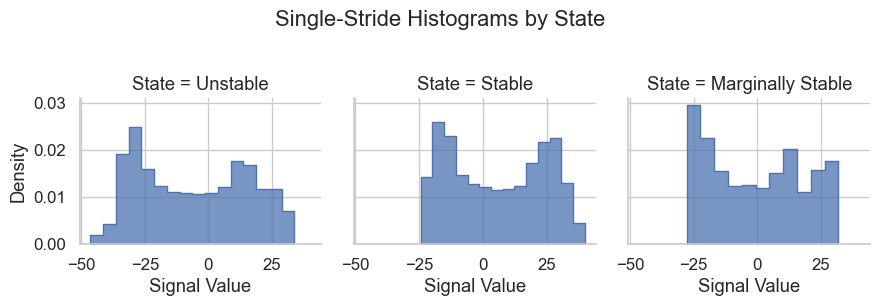

Generating per-stride histogram overlay...


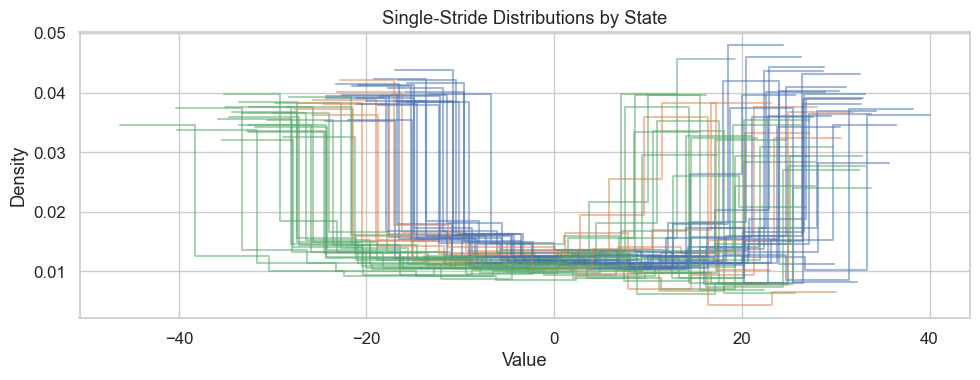

Generating time series with state overlay...


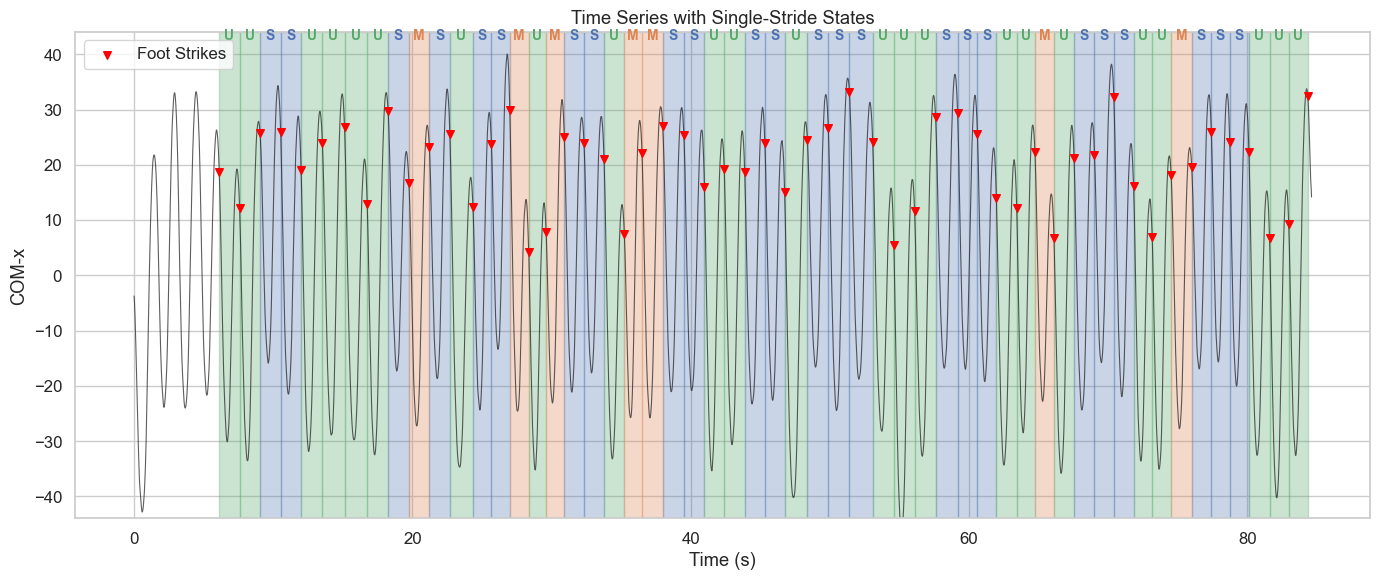


DISTRIBUTION-BASED MSM RESULTS

Total strides analyzed: 54
Average stride duration: 1.449 ± 0.094s

VALIDATION METRICS:
--------------------
GMM Reconstruction RMSE: 0.0577
  → Excellent GMM reconstruction quality
Clustering Silhouette Score: 0.188
  → Poor clustering - consider different parameters
Variance Explained by Clustering: 44.0%
  → Low variance explained - consider more states or different approach

TRANSITION ANALYSIS:
--------------------
Transition Matrix T:
[[0.542 0.083 0.375]
 [0.571 0.143 0.286]
 [0.318 0.182 0.5  ]]

Stationary Distribution Π:
[0.453 0.132 0.415]

Mean Dwell Times τ (strides):
[2.182 1.167 2.   ]

STATE STATISTICS:
--------------------

Stable:
  Fraction of strides: 0.444
  Mean duration: 1.447s
  Duration std: 0.082s
  Histogram peak bin: 6
  Histogram entropy: 1.755

Marginally Stable:
  Fraction of strides: 0.130
  Mean duration: 1.393s
  Duration std: 0.088s
  Histogram peak bin: 2
  Histogram entropy: 1.828

Unstable:
  Fraction of strides: 0.

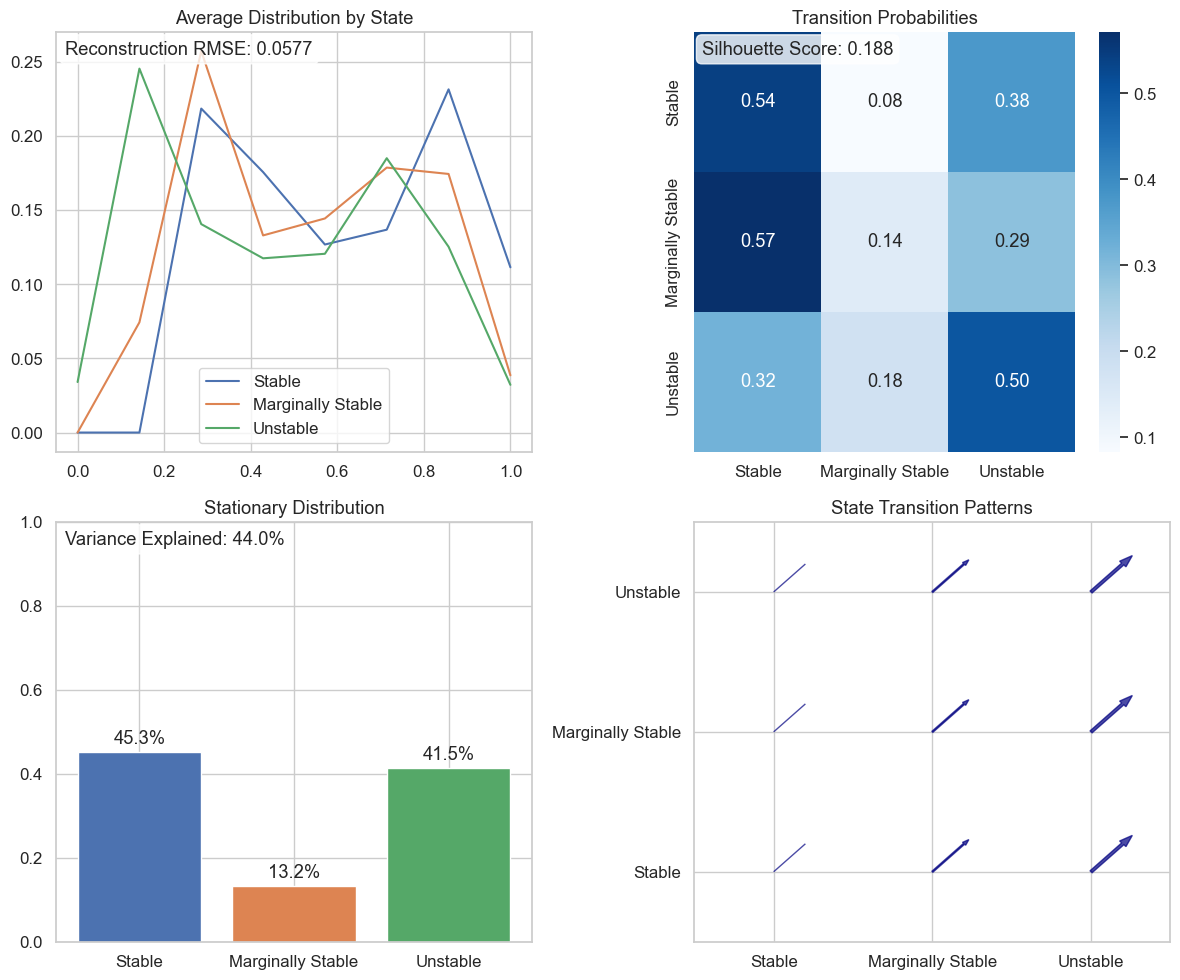


STATE SEQUENCE ANALYSIS

Found 29 state runs

Stable:
  Number of runs: 11
  Mean run length: 2.2 strides
  Max run length: 3 strides
  Min run length: 1 strides

Marginally Stable:
  Number of runs: 6
  Mean run length: 1.2 strides
  Max run length: 2 strides
  Min run length: 1 strides

Unstable:
  Number of runs: 12
  Mean run length: 1.9 strides
  Max run length: 4 strides
  Min run length: 1 strides

Generating validation plots...


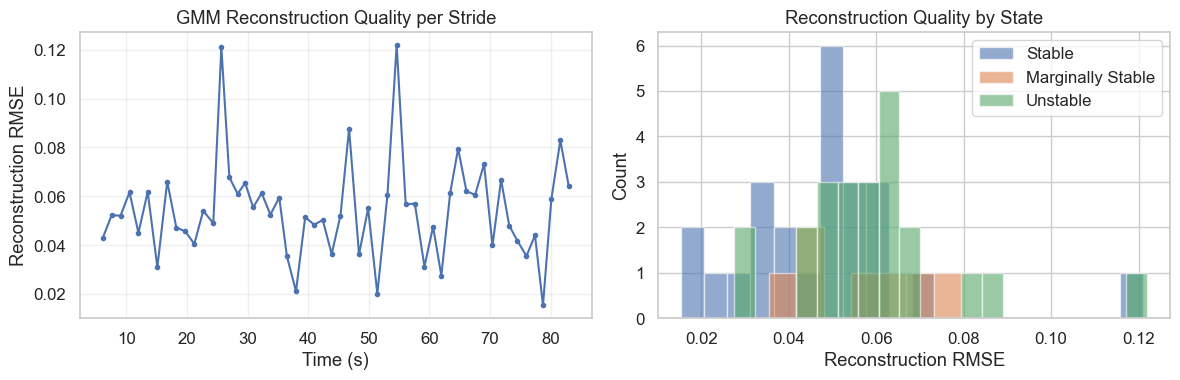


SUMMARY ASSESSMENT
Overall Quality Score: 3/6
Quality Notes:
  • Excellent GMM reconstruction
  • Poorly separated states
  • Low variance explained
  • Balanced state distribution

State Distribution: ['44.4%', '13.0%', '42.6%']
Dominant State: Stable


In [67]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
from preprocessing import preprocess_signal

def main():
    cwd = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.4" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "SWS" / "4"/ "markers.nc"
    events_file = cwd.parent / ".." / "data" / "CGA" / "04" / "SWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) Load & preprocess COM-x
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs, poly_order=1,hp_cutoff=0.1, lp_cutoff=30.0)
    
    # Print signal characteristics for validation context
    print(f"Signal range: [{ts.min():.2f}, {ts.max():.2f}]")
    print(f"Signal std: {ts.std():.2f}")
    
    # 2) Extract foot strike events
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=5")["time"].values)
    
    avg_stride = np.mean(np.diff(strikes))
    win_samps = int(round(avg_stride * fs))
    print(f"Found {len(strikes)} foot strikes")
    print(f"Time range: {strikes[0]:.2f}s to {strikes[-1]:.2f}s")
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) Build & run DistributionMSM
    msm = DistributionMSM_Strides(
        patient_id="04_SWS", 
        n_states=3,
        n_bins=8, n_grid_points=100
    )
    
    msm.plot_gmm_reconstruction_error_distribution()
    # Fit the model
    msm.fit(ts, strikes, fs)
    df = msm.metrics_history
    states = df['state'].values
    
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}

    # 4) Overlaid kernel-density estimates (KDEs)
    print("\nGenerating KDE plots...")
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Gather all samples in strides of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(row.time*fs): int(row.time*fs + row.duration*fs)]
            for _, row in df.iloc[idxs].iterrows()
        ])
        if len(data) > 0:
            # Compute & plot KDE
            kde = gaussian_kde(data)
            xs = np.linspace(data.min(), data.max(), 200)
            plt.plot(xs, kde(xs), color=colors[st], label=label)
    
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Faceted histograms via Seaborn
    print("Generating faceted histograms...")
    # Build a "long" DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st = int(row.state)
        seg = ts[int(row.time * fs): int(row.time * fs) + int(row.duration * fs)]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value", stat="density", element="step", fill=True)
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()

    # 6) Per-stride histograms colored by state
    print("Generating per-stride histogram overlay...")
    plt.figure(figsize=(10, 4))
    for _, row in df.iterrows():
        st = int(row.state)
        start = int(row.time * fs)
        seg = ts[start: start + int(row.duration * fs)]
        sns.histplot(seg, bins=msm.n_bins, stat='density', element='step', 
                    fill=False, color=cmap[st], alpha=0.5)
    
    plt.title("Single-Stride Distributions by State")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # 7) Time series with S/M/U overlay
    print("Generating time series with state overlay...")
    letters = {0: "S", 1: "M", 2: "U"}
    times = np.arange(len(ts)) / fs
    plt.figure(figsize=(14, 6))
    plt.plot(times, ts, color='k', lw=0.8, alpha=0.7)
    
    for _, row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time + row.duration
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.3)
        plt.text((t0 + t1) / 2, ts.max() * 1.05, letters[st],
                ha='center', va='bottom', color=cmap[st], fontsize=10, fontweight='bold')
    
    # Mark foot strikes
    plt.scatter(strikes, np.interp(strikes, times, ts), 
               color='red', s=30, zorder=5, marker='v', label='Foot Strikes')
    
    plt.title("Time Series with Single-Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-x")
    plt.ylim(ts.min() * 0.95, ts.max() * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    print("\n" + "="*50)
    print("DISTRIBUTION-BASED MSM RESULTS")
    print("="*50)
    print(f"\nTotal strides analyzed: {len(df)}")
    print(f"Average stride duration: {df['duration'].mean():.3f} ± {df['duration'].std():.3f}s")
    
    # Print validation metrics first
    print("\nVALIDATION METRICS:")
    print("-" * 20)
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            print(f"GMM Reconstruction RMSE: {rmse:.4f}")
            # Interpret relative to signal characteristics
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.01:
                print("  → Excellent GMM reconstruction quality")
            elif relative_rmse < 0.05:
                print("  → Good GMM reconstruction quality")
            elif relative_rmse < 0.1:
                print("  → Reasonable GMM reconstruction quality")
            else:
                print("  → Poor GMM reconstruction quality")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            print(f"Clustering Silhouette Score: {sil:.3f}")
            if sil > 0.7:
                print("  → Strong, well-separated clusters")
            elif sil > 0.5:
                print("  → Reasonable clustering quality")
            elif sil > 0.25:
                print("  → Weak clustering - states may overlap")
            else:
                print("  → Poor clustering - consider different parameters")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            print(f"Variance Explained by Clustering: {var_exp:.1%}")
            if var_exp > 0.7:
                print("  → Clustering captures most histogram variance")
            elif var_exp > 0.5:
                print("  → Clustering captures reasonable variance")
            else:
                print("  → Low variance explained - consider more states or different approach")

    print("\nTRANSITION ANALYSIS:")
    print("-" * 20)
    print("Transition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (strides):")
    print(np.round(tau, 3))
    
    print("\nSTATE STATISTICS:")
    print("-" * 20)
    for i in range(msm.n_states):
        state_data = df[df['state'] == i]
        print(f"\n{msm.state_labels[i]}:")
        print(f"  Fraction of strides: {len(state_data)/len(df):.3f}")
        print(f"  Mean duration: {state_data['duration'].mean():.3f}s")
        print(f"  Duration std: {state_data['duration'].std():.3f}s")
        
        # Show mean histogram characteristics
        cols = [c for c in state_data.columns if c.startswith('bin_')]
        mean_hist = state_data[cols].mean().values
        print(f"  Histogram peak bin: {np.argmax(mean_hist)}")
        print(f"  Histogram entropy: {-np.sum(mean_hist * np.log(mean_hist + 1e-10)):.3f}")

    # 9) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()

    # 10) State sequence analysis
    print("\n" + "="*50)
    print("STATE SEQUENCE ANALYSIS")
    print("="*50)
    
    # Find runs of consecutive states
    state_runs = []
    current_state = states[0]
    run_start = 0
    
    for i in range(1, len(states)):
        if states[i] != current_state:
            state_runs.append({
                'state': current_state,
                'start_idx': run_start,
                'end_idx': i-1,
                'length': i - run_start,
                'start_time': df.iloc[run_start]['time'],
                'end_time': df.iloc[i-1]['time']
            })
            current_state = states[i]
            run_start = i
    
    # Add final run
    state_runs.append({
        'state': current_state,
        'start_idx': run_start,
        'end_idx': len(states)-1,
        'length': len(states) - run_start,
        'start_time': df.iloc[run_start]['time'],
        'end_time': df.iloc[-1]['time']
    })
    
    # Analyze runs
    print(f"\nFound {len(state_runs)} state runs")
    for state in range(msm.n_states):
        runs = [r for r in state_runs if r['state'] == state]
        if runs:
            lengths = [r['length'] for r in runs]
            print(f"\n{msm.state_labels[state]}:")
            print(f"  Number of runs: {len(runs)}")
            print(f"  Mean run length: {np.mean(lengths):.1f} strides")
            print(f"  Max run length: {np.max(lengths)} strides")
            print(f"  Min run length: {np.min(lengths)} strides")

    # 11) Additional validation plots
    print("\nGenerating validation plots...")
    
    # Plot reconstruction quality per stride
    if 'gmm_reconstruction_rmse_per_stride' in msm.validation_metrics:
        plt.figure(figsize=(12, 4))
        per_stride_rmse = msm.validation_metrics['gmm_reconstruction_rmse_per_stride']
        
        plt.subplot(1, 2, 1)
        plt.plot(df['time'], per_stride_rmse, 'o-', markersize=3)
        plt.xlabel('Time (s)')
        plt.ylabel('Reconstruction RMSE')
        plt.title('GMM Reconstruction Quality per Stride')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        for state in range(msm.n_states):
            state_mask = df['state'] == state
            state_rmse = per_stride_rmse[state_mask]
            if len(state_rmse) == 0:
                continue

            # Choose bins = min(requested, unique‐value count) or use 'auto'
            unique_vals = np.unique(state_rmse)
            nbins = min(20, len(unique_vals)) if len(unique_vals)>1 else 1

            plt.hist(
                state_rmse,
                bins=nbins,                     # adapt to data
                alpha=0.6,
                label=msm.state_labels[state],
                color=colors[state],
            )
            plt.xlabel('Reconstruction RMSE')
        plt.ylabel('Count')
        plt.title('Reconstruction Quality by State')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Summary statistics
    print("\n" + "="*50)
    print("SUMMARY ASSESSMENT")
    print("="*50)
    
    # Overall quality assessment
    quality_score = 0
    quality_notes = []
    
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.05:
                quality_score += 2
                quality_notes.append("Excellent GMM reconstruction")
            elif relative_rmse < 0.1:
                quality_score += 1
                quality_notes.append("Good GMM reconstruction")
            else:
                quality_notes.append("Poor GMM reconstruction")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            if sil > 0.5:
                quality_score += 2
                quality_notes.append("Well-separated states")
            elif sil > 0.25:
                quality_score += 1
                quality_notes.append("Moderately separated states")
            else:
                quality_notes.append("Poorly separated states")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            if var_exp > 0.6:
                quality_score += 1
                quality_notes.append("Good variance explained")
            else:
                quality_notes.append("Low variance explained")
    
    # Check if states are balanced
    state_fractions = [np.mean(states == i) for i in range(msm.n_states)]
    if min(state_fractions) > 0.1:  # All states have at least 10% of data
        quality_score += 1
        quality_notes.append("Balanced state distribution")
    else:
        quality_notes.append("Imbalanced state distribution")
    
    print(f"Overall Quality Score: {quality_score}/6")
    print("Quality Notes:")
    for note in quality_notes:
        print(f"  • {note}")
    
    print(f"\nState Distribution: {[f'{f:.1%}' for f in state_fractions]}")
    print(f"Dominant State: {msm.state_labels[np.argmax(state_fractions)]}")
    
    return msm, summary

if __name__ == "__main__":
    model, metrics = main()

### 38 - PWS

Signal range: [-50.36, 50.28]
Signal std: 20.82
Found 95 foot strikes
Time range: 6.10s to 134.22s
Single-stride window = 136 samples (~1.36s)
No per‑stride GMM RMSE data.
Processing patient 04_SWS using stride-based histograms…
Created histograms from 94 valid strides
Average stride duration: 1.363s ± 0.046s
Identifying stability states via GMM…
GMM reconstruction RMSE: 0.0726
Clustering silhouette score: 0.195
Clustering quality: Poor clustering
Variance explained by clustering: 35.0%
Computing transition matrix…
Computing stationary distribution…

Stability metrics for 04_SWS:
  frac_state_0: 0.468
  frac_state_1: 0.372
  frac_state_2: 0.160
  gmm_reconstruction_rmse: 0.073
  clustering_silhouette_score: 0.195
  variance_explained_by_clustering: 0.350

Validation Summary:
  GMM reconstruction quality: RMSE = 0.0726
  Clustering quality: Silhouette = 0.195
  Variance explained by clustering: 35.0%

Generating KDE plots...


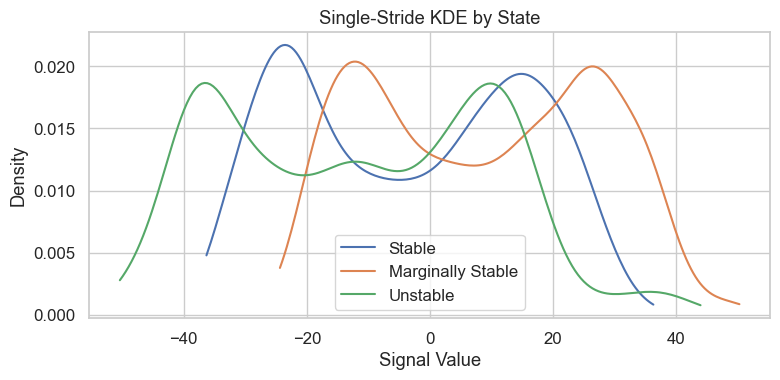

Generating faceted histograms...


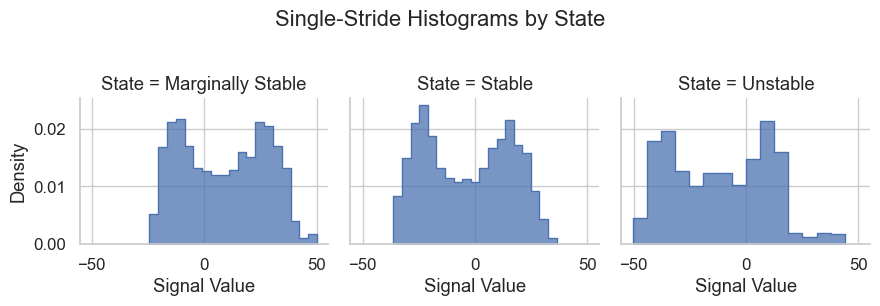

Generating per-stride histogram overlay...


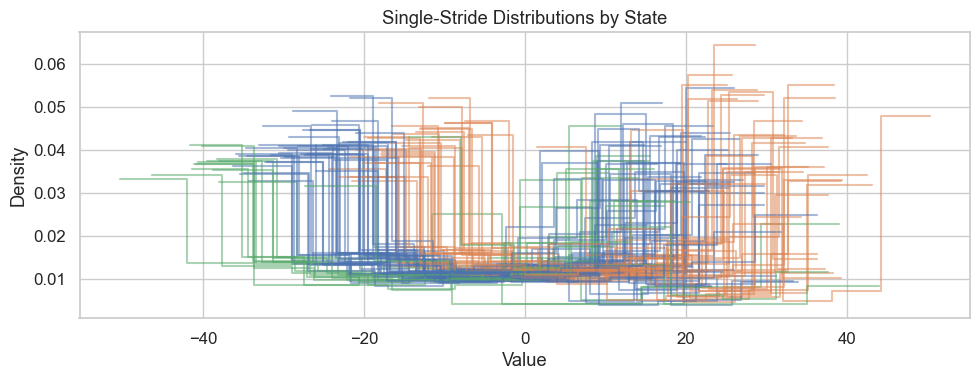

Generating time series with state overlay...


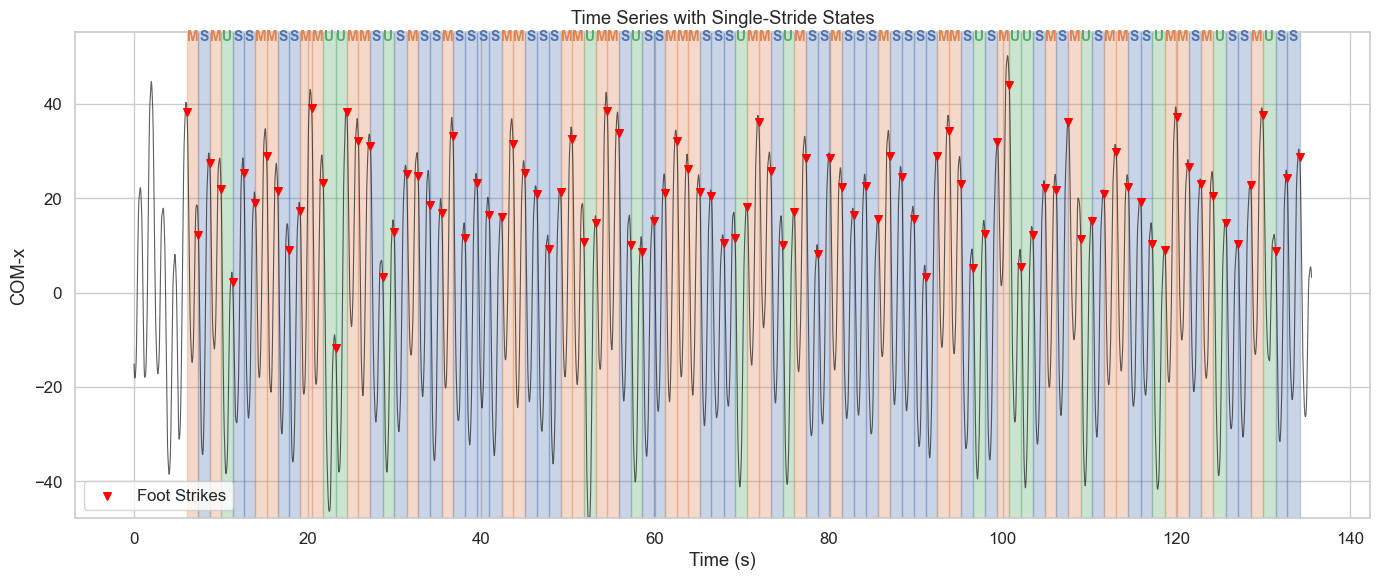


DISTRIBUTION-BASED MSM RESULTS

Total strides analyzed: 94
Average stride duration: 1.363 ± 0.046s

VALIDATION METRICS:
--------------------
GMM Reconstruction RMSE: 0.0726
  → Excellent GMM reconstruction quality
Clustering Silhouette Score: 0.195
  → Poor clustering - consider different parameters
Variance Explained by Clustering: 35.0%
  → Low variance explained - consider more states or different approach

TRANSITION ANALYSIS:
--------------------
Transition Matrix T:
[[0.465 0.395 0.14 ]
 [0.457 0.343 0.2  ]
 [0.533 0.333 0.133]]

Stationary Distribution Π:
[0.473 0.366 0.161]

Mean Dwell Times τ (strides):
[1.87  1.522 1.154]

STATE STATISTICS:
--------------------

Stable:
  Fraction of strides: 0.468
  Mean duration: 1.373s
  Duration std: 0.044s
  Histogram peak bin: 2
  Histogram entropy: 1.711

Marginally Stable:
  Fraction of strides: 0.372
  Mean duration: 1.347s
  Duration std: 0.040s
  Histogram peak bin: 6
  Histogram entropy: 1.694

Unstable:
  Fraction of strides: 0.

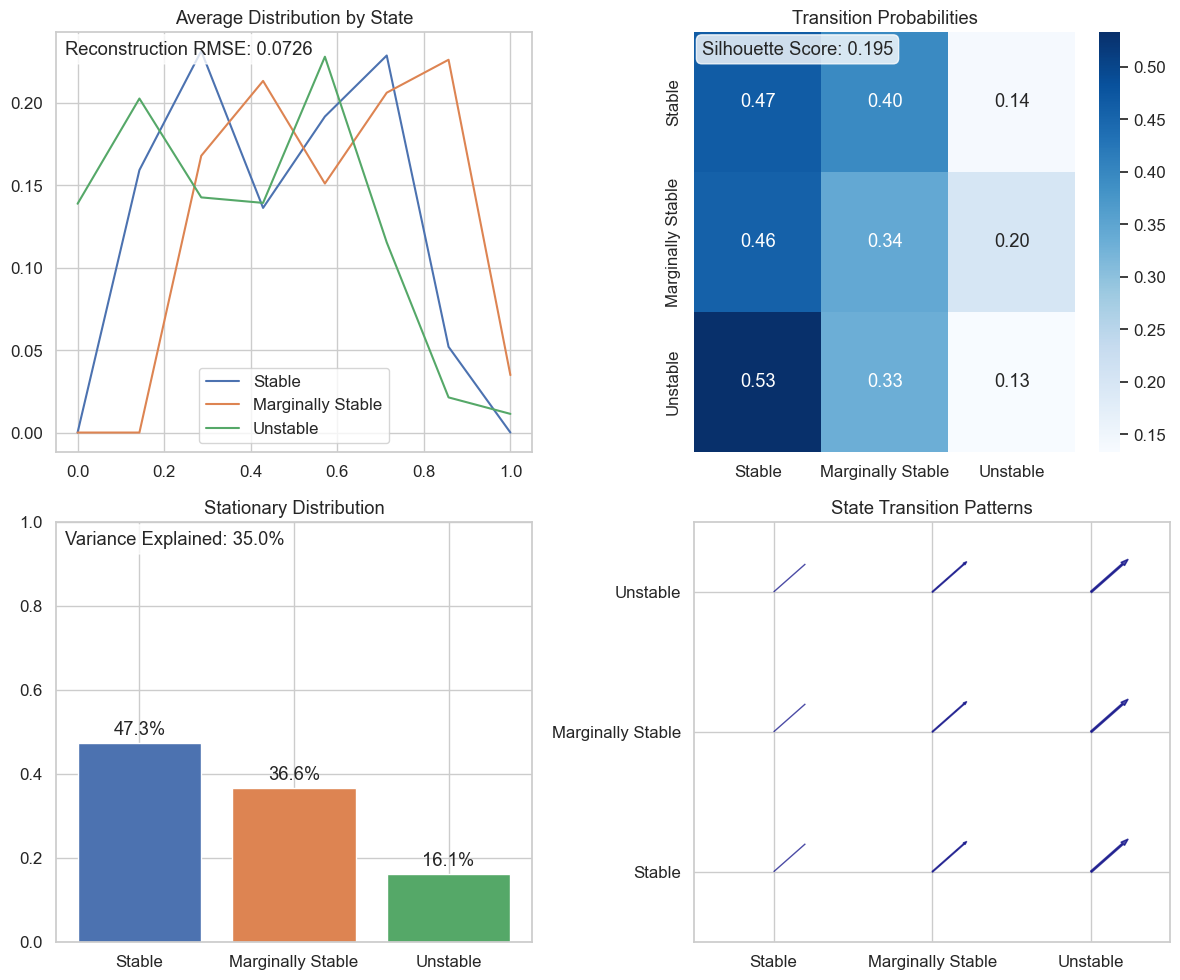


STATE SEQUENCE ANALYSIS

Found 60 state runs

Stable:
  Number of runs: 24
  Mean run length: 1.8 strides
  Max run length: 4 strides
  Min run length: 1 strides

Marginally Stable:
  Number of runs: 23
  Mean run length: 1.5 strides
  Max run length: 3 strides
  Min run length: 1 strides

Unstable:
  Number of runs: 13
  Mean run length: 1.2 strides
  Max run length: 2 strides
  Min run length: 1 strides

Generating validation plots...


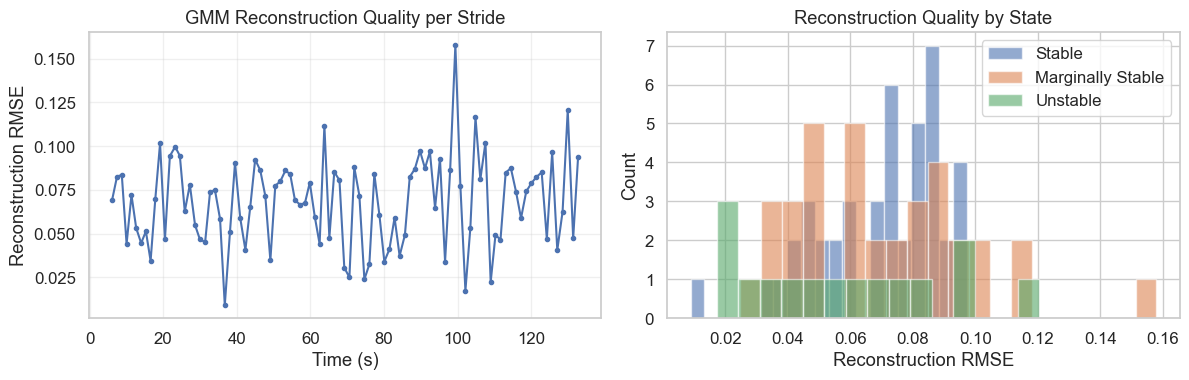


SUMMARY ASSESSMENT
Overall Quality Score: 3/6
Quality Notes:
  • Excellent GMM reconstruction
  • Poorly separated states
  • Low variance explained
  • Balanced state distribution

State Distribution: ['46.8%', '37.2%', '16.0%']
Dominant State: Stable


In [68]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
from preprocessing import preprocess_signal

def main():
    cwd = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.4" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "38" / "PWS" / "4"/ "markers.nc"
    events_file = cwd.parent / ".." / "data" / "CGA" / "38" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) Load & preprocess COM-x
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs, poly_order=1,hp_cutoff=0.1, lp_cutoff=30.0)
    
    # Print signal characteristics for validation context
    print(f"Signal range: [{ts.min():.2f}, {ts.max():.2f}]")
    print(f"Signal std: {ts.std():.2f}")
    
    # 2) Extract foot strike events
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=5")["time"].values)
    
    avg_stride = np.mean(np.diff(strikes))
    win_samps = int(round(avg_stride * fs))
    print(f"Found {len(strikes)} foot strikes")
    print(f"Time range: {strikes[0]:.2f}s to {strikes[-1]:.2f}s")
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) Build & run DistributionMSM
    msm = DistributionMSM_Strides(
        patient_id="04_SWS", 
        n_states=3,
        n_bins=8, n_grid_points=100
    )
    
    msm.plot_gmm_reconstruction_error_distribution()
    # Fit the model
    msm.fit(ts, strikes, fs)
    df = msm.metrics_history
    states = df['state'].values
    
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}

    # 4) Overlaid kernel-density estimates (KDEs)
    print("\nGenerating KDE plots...")
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Gather all samples in strides of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(row.time*fs): int(row.time*fs + row.duration*fs)]
            for _, row in df.iloc[idxs].iterrows()
        ])
        if len(data) > 0:
            # Compute & plot KDE
            kde = gaussian_kde(data)
            xs = np.linspace(data.min(), data.max(), 200)
            plt.plot(xs, kde(xs), color=colors[st], label=label)
    
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Faceted histograms via Seaborn
    print("Generating faceted histograms...")
    # Build a "long" DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st = int(row.state)
        seg = ts[int(row.time * fs): int(row.time * fs) + int(row.duration * fs)]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value", stat="density", element="step", fill=True)
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()

    # 6) Per-stride histograms colored by state
    print("Generating per-stride histogram overlay...")
    plt.figure(figsize=(10, 4))
    for _, row in df.iterrows():
        st = int(row.state)
        start = int(row.time * fs)
        seg = ts[start: start + int(row.duration * fs)]
        sns.histplot(seg, bins=msm.n_bins, stat='density', element='step', 
                    fill=False, color=cmap[st], alpha=0.5)
    
    plt.title("Single-Stride Distributions by State")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # 7) Time series with S/M/U overlay
    print("Generating time series with state overlay...")
    letters = {0: "S", 1: "M", 2: "U"}
    times = np.arange(len(ts)) / fs
    plt.figure(figsize=(14, 6))
    plt.plot(times, ts, color='k', lw=0.8, alpha=0.7)
    
    for _, row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time + row.duration
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.3)
        plt.text((t0 + t1) / 2, ts.max() * 1.05, letters[st],
                ha='center', va='bottom', color=cmap[st], fontsize=10, fontweight='bold')
    
    # Mark foot strikes
    plt.scatter(strikes, np.interp(strikes, times, ts), 
               color='red', s=30, zorder=5, marker='v', label='Foot Strikes')
    
    plt.title("Time Series with Single-Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-x")
    plt.ylim(ts.min() * 0.95, ts.max() * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    print("\n" + "="*50)
    print("DISTRIBUTION-BASED MSM RESULTS")
    print("="*50)
    print(f"\nTotal strides analyzed: {len(df)}")
    print(f"Average stride duration: {df['duration'].mean():.3f} ± {df['duration'].std():.3f}s")
    
    # Print validation metrics first
    print("\nVALIDATION METRICS:")
    print("-" * 20)
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            print(f"GMM Reconstruction RMSE: {rmse:.4f}")
            # Interpret relative to signal characteristics
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.01:
                print("  → Excellent GMM reconstruction quality")
            elif relative_rmse < 0.05:
                print("  → Good GMM reconstruction quality")
            elif relative_rmse < 0.1:
                print("  → Reasonable GMM reconstruction quality")
            else:
                print("  → Poor GMM reconstruction quality")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            print(f"Clustering Silhouette Score: {sil:.3f}")
            if sil > 0.7:
                print("  → Strong, well-separated clusters")
            elif sil > 0.5:
                print("  → Reasonable clustering quality")
            elif sil > 0.25:
                print("  → Weak clustering - states may overlap")
            else:
                print("  → Poor clustering - consider different parameters")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            print(f"Variance Explained by Clustering: {var_exp:.1%}")
            if var_exp > 0.7:
                print("  → Clustering captures most histogram variance")
            elif var_exp > 0.5:
                print("  → Clustering captures reasonable variance")
            else:
                print("  → Low variance explained - consider more states or different approach")

    print("\nTRANSITION ANALYSIS:")
    print("-" * 20)
    print("Transition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (strides):")
    print(np.round(tau, 3))
    
    print("\nSTATE STATISTICS:")
    print("-" * 20)
    for i in range(msm.n_states):
        state_data = df[df['state'] == i]
        print(f"\n{msm.state_labels[i]}:")
        print(f"  Fraction of strides: {len(state_data)/len(df):.3f}")
        print(f"  Mean duration: {state_data['duration'].mean():.3f}s")
        print(f"  Duration std: {state_data['duration'].std():.3f}s")
        
        # Show mean histogram characteristics
        cols = [c for c in state_data.columns if c.startswith('bin_')]
        mean_hist = state_data[cols].mean().values
        print(f"  Histogram peak bin: {np.argmax(mean_hist)}")
        print(f"  Histogram entropy: {-np.sum(mean_hist * np.log(mean_hist + 1e-10)):.3f}")

    # 9) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()

    # 10) State sequence analysis
    print("\n" + "="*50)
    print("STATE SEQUENCE ANALYSIS")
    print("="*50)
    
    # Find runs of consecutive states
    state_runs = []
    current_state = states[0]
    run_start = 0
    
    for i in range(1, len(states)):
        if states[i] != current_state:
            state_runs.append({
                'state': current_state,
                'start_idx': run_start,
                'end_idx': i-1,
                'length': i - run_start,
                'start_time': df.iloc[run_start]['time'],
                'end_time': df.iloc[i-1]['time']
            })
            current_state = states[i]
            run_start = i
    
    # Add final run
    state_runs.append({
        'state': current_state,
        'start_idx': run_start,
        'end_idx': len(states)-1,
        'length': len(states) - run_start,
        'start_time': df.iloc[run_start]['time'],
        'end_time': df.iloc[-1]['time']
    })
    
    # Analyze runs
    print(f"\nFound {len(state_runs)} state runs")
    for state in range(msm.n_states):
        runs = [r for r in state_runs if r['state'] == state]
        if runs:
            lengths = [r['length'] for r in runs]
            print(f"\n{msm.state_labels[state]}:")
            print(f"  Number of runs: {len(runs)}")
            print(f"  Mean run length: {np.mean(lengths):.1f} strides")
            print(f"  Max run length: {np.max(lengths)} strides")
            print(f"  Min run length: {np.min(lengths)} strides")

    # 11) Additional validation plots
    print("\nGenerating validation plots...")
    
    # Plot reconstruction quality per stride
    if 'gmm_reconstruction_rmse_per_stride' in msm.validation_metrics:
        plt.figure(figsize=(12, 4))
        per_stride_rmse = msm.validation_metrics['gmm_reconstruction_rmse_per_stride']
        
        plt.subplot(1, 2, 1)
        plt.plot(df['time'], per_stride_rmse, 'o-', markersize=3)
        plt.xlabel('Time (s)')
        plt.ylabel('Reconstruction RMSE')
        plt.title('GMM Reconstruction Quality per Stride')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        for state in range(msm.n_states):
            state_mask = df['state'] == state
            state_rmse = per_stride_rmse[state_mask]
            if len(state_rmse) == 0:
                continue

            # Choose bins = min(requested, unique‐value count) or use 'auto'
            unique_vals = np.unique(state_rmse)
            nbins = min(20, len(unique_vals)) if len(unique_vals)>1 else 1

            plt.hist(
                state_rmse,
                bins=nbins,                     # adapt to data
                alpha=0.6,
                label=msm.state_labels[state],
                color=colors[state],
            )
            plt.xlabel('Reconstruction RMSE')
        plt.ylabel('Count')
        plt.title('Reconstruction Quality by State')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Summary statistics
    print("\n" + "="*50)
    print("SUMMARY ASSESSMENT")
    print("="*50)
    
    # Overall quality assessment
    quality_score = 0
    quality_notes = []
    
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.05:
                quality_score += 2
                quality_notes.append("Excellent GMM reconstruction")
            elif relative_rmse < 0.1:
                quality_score += 1
                quality_notes.append("Good GMM reconstruction")
            else:
                quality_notes.append("Poor GMM reconstruction")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            if sil > 0.5:
                quality_score += 2
                quality_notes.append("Well-separated states")
            elif sil > 0.25:
                quality_score += 1
                quality_notes.append("Moderately separated states")
            else:
                quality_notes.append("Poorly separated states")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            if var_exp > 0.6:
                quality_score += 1
                quality_notes.append("Good variance explained")
            else:
                quality_notes.append("Low variance explained")
    
    # Check if states are balanced
    state_fractions = [np.mean(states == i) for i in range(msm.n_states)]
    if min(state_fractions) > 0.1:  # All states have at least 10% of data
        quality_score += 1
        quality_notes.append("Balanced state distribution")
    else:
        quality_notes.append("Imbalanced state distribution")
    
    print(f"Overall Quality Score: {quality_score}/6")
    print("Quality Notes:")
    for note in quality_notes:
        print(f"  • {note}")
    
    print(f"\nState Distribution: {[f'{f:.1%}' for f in state_fractions]}")
    print(f"Dominant State: {msm.state_labels[np.argmax(state_fractions)]}")
    
    return msm, summary

if __name__ == "__main__":
    model, metrics = main()

### 38 - FWS

Signal range: [-52.48, 60.28]
Signal std: 21.36
Found 95 foot strikes
Time range: 5.15s to 121.68s
Single-stride window = 124 samples (~1.24s)
No per‑stride GMM RMSE data.
Processing patient 38_FWS using stride-based histograms…
Created histograms from 94 valid strides
Average stride duration: 1.240s ± 0.025s
Identifying stability states via GMM…
GMM reconstruction RMSE: 0.0874
Clustering silhouette score: 0.234
Clustering quality: Poor clustering
Variance explained by clustering: 44.9%
Computing transition matrix…
Computing stationary distribution…

Stability metrics for 38_FWS:
  frac_state_0: 0.330
  frac_state_1: 0.404
  frac_state_2: 0.266
  gmm_reconstruction_rmse: 0.087
  clustering_silhouette_score: 0.234
  variance_explained_by_clustering: 0.449

Validation Summary:
  GMM reconstruction quality: RMSE = 0.0874
  Clustering quality: Silhouette = 0.234
  Variance explained by clustering: 44.9%

Generating KDE plots...


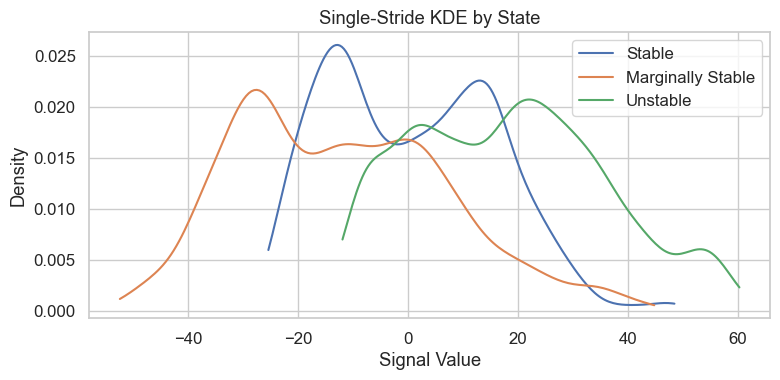

Generating faceted histograms...


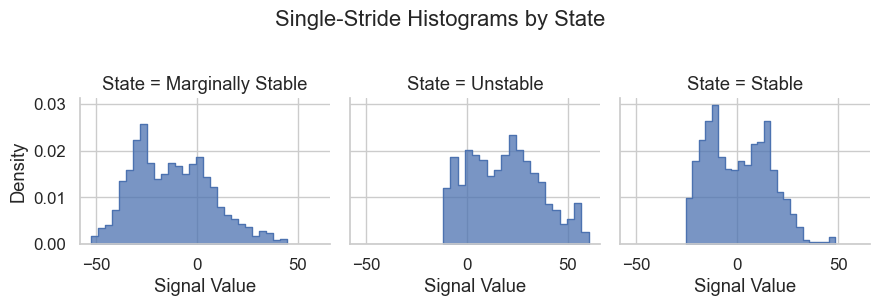

Generating per-stride histogram overlay...


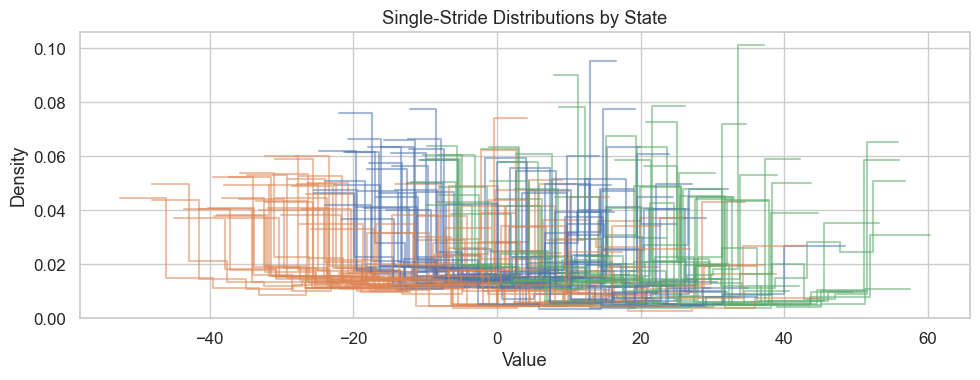

Generating time series with state overlay...


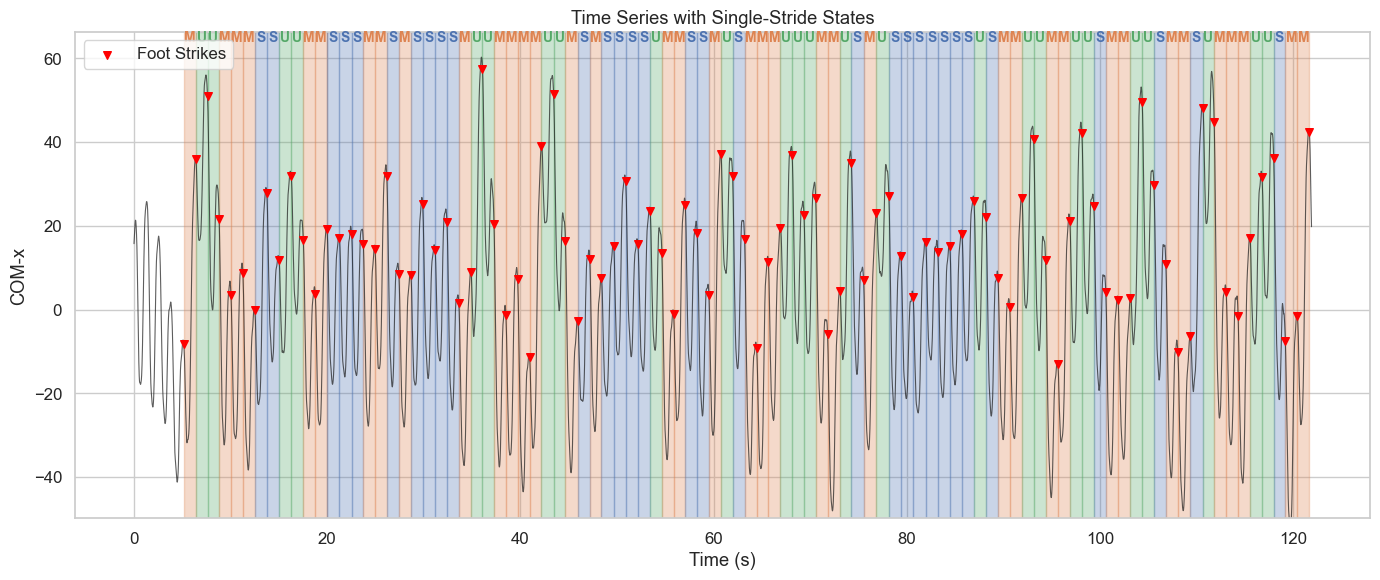


DISTRIBUTION-BASED MSM RESULTS

Total strides analyzed: 94
Average stride duration: 1.240 ± 0.025s

VALIDATION METRICS:
--------------------
GMM Reconstruction RMSE: 0.0874
  → Excellent GMM reconstruction quality
Clustering Silhouette Score: 0.234
  → Poor clustering - consider different parameters
Variance Explained by Clustering: 44.9%
  → Low variance explained - consider more states or different approach

TRANSITION ANALYSIS:
--------------------
Transition Matrix T:
[[0.516 0.355 0.129]
 [0.216 0.486 0.297]
 [0.28  0.32  0.4  ]]

Stationary Distribution Π:
[0.333 0.398 0.269]

Mean Dwell Times τ (strides):
[2.067 1.947 1.667]

STATE STATISTICS:
--------------------

Stable:
  Fraction of strides: 0.330
  Mean duration: 1.252s
  Duration std: 0.023s
  Histogram peak bin: 2
  Histogram entropy: 1.435

Marginally Stable:
  Fraction of strides: 0.404
  Mean duration: 1.235s
  Duration std: 0.021s
  Histogram peak bin: 1
  Histogram entropy: 1.705

Unstable:
  Fraction of strides: 0.

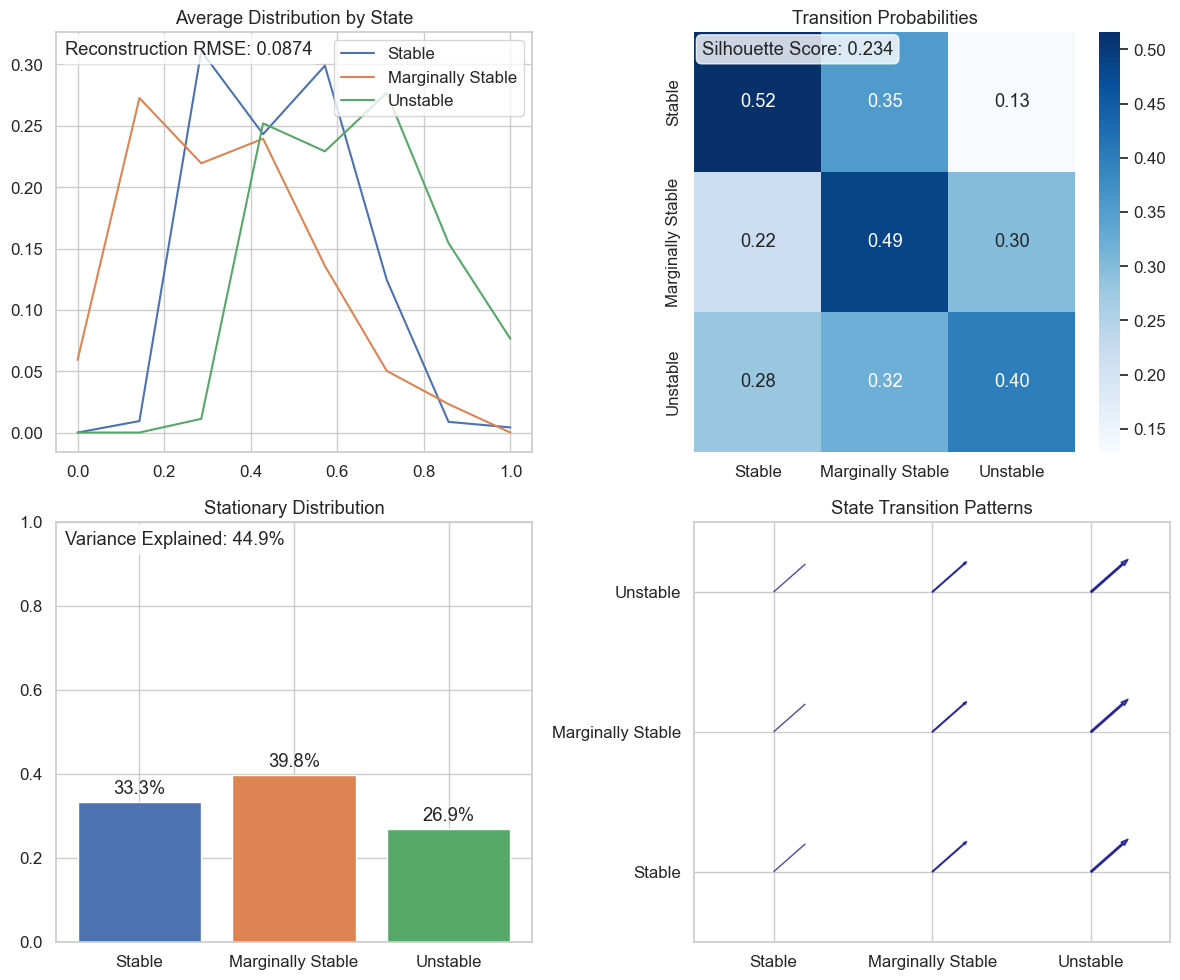


STATE SEQUENCE ANALYSIS

Found 50 state runs

Stable:
  Number of runs: 15
  Mean run length: 2.1 strides
  Max run length: 7 strides
  Min run length: 1 strides

Marginally Stable:
  Number of runs: 20
  Mean run length: 1.9 strides
  Max run length: 4 strides
  Min run length: 1 strides

Unstable:
  Number of runs: 15
  Mean run length: 1.7 strides
  Max run length: 3 strides
  Min run length: 1 strides

Generating validation plots...


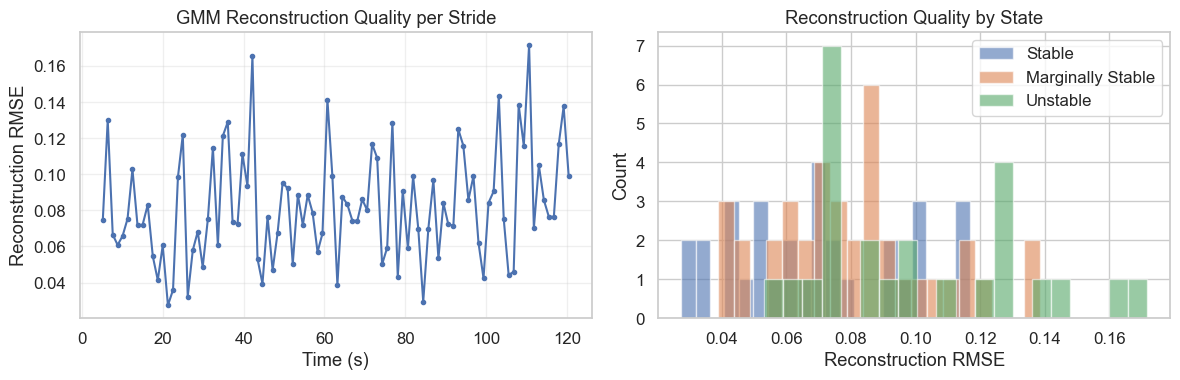


SUMMARY ASSESSMENT
Overall Quality Score: 3/6
Quality Notes:
  • Excellent GMM reconstruction
  • Poorly separated states
  • Low variance explained
  • Balanced state distribution

State Distribution: ['33.0%', '40.4%', '26.6%']
Dominant State: Marginally Stable


In [69]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
from preprocessing import preprocess_signal

def main():
    cwd = Path.cwd()
    # marker_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.3" /"markers.nc"
    # events_file = cwd.parent / ".." /"data"/"PBT"/"Young"/"Cereneo_SR_13"/"Pre.4" /"events.nc"
    marker_file = cwd.parent / ".." / "data" / "CGA" / "38" / "FWS" / "4"/ "markers.nc"
    events_file = cwd.parent / ".." / "data" / "CGA" / "38" / "FWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) Load & preprocess COM-x
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs, poly_order=1,hp_cutoff=0.1, lp_cutoff=30.0)
    
    # Print signal characteristics for validation context
    print(f"Signal range: [{ts.min():.2f}, {ts.max():.2f}]")
    print(f"Signal std: {ts.std():.2f}")
    
    # 2) Extract foot strike events
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=5")["time"].values)
    
    avg_stride = np.mean(np.diff(strikes))
    win_samps = int(round(avg_stride * fs))
    print(f"Found {len(strikes)} foot strikes")
    print(f"Time range: {strikes[0]:.2f}s to {strikes[-1]:.2f}s")
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) Build & run DistributionMSM
    msm = DistributionMSM_Strides(
        patient_id="38_FWS", 
        n_states=3,
        n_bins=8, n_grid_points=100
    )
    
    msm.plot_gmm_reconstruction_error_distribution()
    # Fit the model
    msm.fit(ts, strikes, fs)
    df = msm.metrics_history
    states = df['state'].values
    
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}

    # 4) Overlaid kernel-density estimates (KDEs)
    print("\nGenerating KDE plots...")
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Gather all samples in strides of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(row.time*fs): int(row.time*fs + row.duration*fs)]
            for _, row in df.iloc[idxs].iterrows()
        ])
        if len(data) > 0:
            # Compute & plot KDE
            kde = gaussian_kde(data)
            xs = np.linspace(data.min(), data.max(), 200)
            plt.plot(xs, kde(xs), color=colors[st], label=label)
    
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Faceted histograms via Seaborn
    print("Generating faceted histograms...")
    # Build a "long" DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st = int(row.state)
        seg = ts[int(row.time * fs): int(row.time * fs) + int(row.duration * fs)]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value", stat="density", element="step", fill=True)
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()

    # 6) Per-stride histograms colored by state
    print("Generating per-stride histogram overlay...")
    plt.figure(figsize=(10, 4))
    for _, row in df.iterrows():
        st = int(row.state)
        start = int(row.time * fs)
        seg = ts[start: start + int(row.duration * fs)]
        sns.histplot(seg, bins=msm.n_bins, stat='density', element='step', 
                    fill=False, color=cmap[st], alpha=0.5)
    
    plt.title("Single-Stride Distributions by State")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # 7) Time series with S/M/U overlay
    print("Generating time series with state overlay...")
    letters = {0: "S", 1: "M", 2: "U"}
    times = np.arange(len(ts)) / fs
    plt.figure(figsize=(14, 6))
    plt.plot(times, ts, color='k', lw=0.8, alpha=0.7)
    
    for _, row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time + row.duration
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.3)
        plt.text((t0 + t1) / 2, ts.max() * 1.05, letters[st],
                ha='center', va='bottom', color=cmap[st], fontsize=10, fontweight='bold')
    
    # Mark foot strikes
    plt.scatter(strikes, np.interp(strikes, times, ts), 
               color='red', s=30, zorder=5, marker='v', label='Foot Strikes')
    
    plt.title("Time Series with Single-Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-x")
    plt.ylim(ts.min() * 0.95, ts.max() * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    print("\n" + "="*50)
    print("DISTRIBUTION-BASED MSM RESULTS")
    print("="*50)
    print(f"\nTotal strides analyzed: {len(df)}")
    print(f"Average stride duration: {df['duration'].mean():.3f} ± {df['duration'].std():.3f}s")
    
    # Print validation metrics first
    print("\nVALIDATION METRICS:")
    print("-" * 20)
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            print(f"GMM Reconstruction RMSE: {rmse:.4f}")
            # Interpret relative to signal characteristics
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.01:
                print("  → Excellent GMM reconstruction quality")
            elif relative_rmse < 0.05:
                print("  → Good GMM reconstruction quality")
            elif relative_rmse < 0.1:
                print("  → Reasonable GMM reconstruction quality")
            else:
                print("  → Poor GMM reconstruction quality")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            print(f"Clustering Silhouette Score: {sil:.3f}")
            if sil > 0.7:
                print("  → Strong, well-separated clusters")
            elif sil > 0.5:
                print("  → Reasonable clustering quality")
            elif sil > 0.25:
                print("  → Weak clustering - states may overlap")
            else:
                print("  → Poor clustering - consider different parameters")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            print(f"Variance Explained by Clustering: {var_exp:.1%}")
            if var_exp > 0.7:
                print("  → Clustering captures most histogram variance")
            elif var_exp > 0.5:
                print("  → Clustering captures reasonable variance")
            else:
                print("  → Low variance explained - consider more states or different approach")

    print("\nTRANSITION ANALYSIS:")
    print("-" * 20)
    print("Transition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (strides):")
    print(np.round(tau, 3))
    
    print("\nSTATE STATISTICS:")
    print("-" * 20)
    for i in range(msm.n_states):
        state_data = df[df['state'] == i]
        print(f"\n{msm.state_labels[i]}:")
        print(f"  Fraction of strides: {len(state_data)/len(df):.3f}")
        print(f"  Mean duration: {state_data['duration'].mean():.3f}s")
        print(f"  Duration std: {state_data['duration'].std():.3f}s")
        
        # Show mean histogram characteristics
        cols = [c for c in state_data.columns if c.startswith('bin_')]
        mean_hist = state_data[cols].mean().values
        print(f"  Histogram peak bin: {np.argmax(mean_hist)}")
        print(f"  Histogram entropy: {-np.sum(mean_hist * np.log(mean_hist + 1e-10)):.3f}")

    # 9) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()

    # 10) State sequence analysis
    print("\n" + "="*50)
    print("STATE SEQUENCE ANALYSIS")
    print("="*50)
    
    # Find runs of consecutive states
    state_runs = []
    current_state = states[0]
    run_start = 0
    
    for i in range(1, len(states)):
        if states[i] != current_state:
            state_runs.append({
                'state': current_state,
                'start_idx': run_start,
                'end_idx': i-1,
                'length': i - run_start,
                'start_time': df.iloc[run_start]['time'],
                'end_time': df.iloc[i-1]['time']
            })
            current_state = states[i]
            run_start = i
    
    # Add final run
    state_runs.append({
        'state': current_state,
        'start_idx': run_start,
        'end_idx': len(states)-1,
        'length': len(states) - run_start,
        'start_time': df.iloc[run_start]['time'],
        'end_time': df.iloc[-1]['time']
    })
    
    # Analyze runs
    print(f"\nFound {len(state_runs)} state runs")
    for state in range(msm.n_states):
        runs = [r for r in state_runs if r['state'] == state]
        if runs:
            lengths = [r['length'] for r in runs]
            print(f"\n{msm.state_labels[state]}:")
            print(f"  Number of runs: {len(runs)}")
            print(f"  Mean run length: {np.mean(lengths):.1f} strides")
            print(f"  Max run length: {np.max(lengths)} strides")
            print(f"  Min run length: {np.min(lengths)} strides")

    # 11) Additional validation plots
    print("\nGenerating validation plots...")
    
    # Plot reconstruction quality per stride
    if 'gmm_reconstruction_rmse_per_stride' in msm.validation_metrics:
        plt.figure(figsize=(12, 4))
        per_stride_rmse = msm.validation_metrics['gmm_reconstruction_rmse_per_stride']
        
        plt.subplot(1, 2, 1)
        plt.plot(df['time'], per_stride_rmse, 'o-', markersize=3)
        plt.xlabel('Time (s)')
        plt.ylabel('Reconstruction RMSE')
        plt.title('GMM Reconstruction Quality per Stride')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        for state in range(msm.n_states):
            state_mask = df['state'] == state
            state_rmse = per_stride_rmse[state_mask]
            if len(state_rmse) == 0:
                continue

            # Choose bins = min(requested, unique‐value count) or use 'auto'
            unique_vals = np.unique(state_rmse)
            nbins = min(20, len(unique_vals)) if len(unique_vals)>1 else 1

            plt.hist(
                state_rmse,
                bins=nbins,                     # adapt to data
                alpha=0.6,
                label=msm.state_labels[state],
                color=colors[state],
            )
            plt.xlabel('Reconstruction RMSE')
        plt.ylabel('Count')
        plt.title('Reconstruction Quality by State')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Summary statistics
    print("\n" + "="*50)
    print("SUMMARY ASSESSMENT")
    print("="*50)
    
    # Overall quality assessment
    quality_score = 0
    quality_notes = []
    
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.05:
                quality_score += 2
                quality_notes.append("Excellent GMM reconstruction")
            elif relative_rmse < 0.1:
                quality_score += 1
                quality_notes.append("Good GMM reconstruction")
            else:
                quality_notes.append("Poor GMM reconstruction")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            if sil > 0.5:
                quality_score += 2
                quality_notes.append("Well-separated states")
            elif sil > 0.25:
                quality_score += 1
                quality_notes.append("Moderately separated states")
            else:
                quality_notes.append("Poorly separated states")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            if var_exp > 0.6:
                quality_score += 1
                quality_notes.append("Good variance explained")
            else:
                quality_notes.append("Low variance explained")
    
    # Check if states are balanced
    state_fractions = [np.mean(states == i) for i in range(msm.n_states)]
    if min(state_fractions) > 0.1:  # All states have at least 10% of data
        quality_score += 1
        quality_notes.append("Balanced state distribution")
    else:
        quality_notes.append("Imbalanced state distribution")
    
    print(f"Overall Quality Score: {quality_score}/6")
    print("Quality Notes:")
    for note in quality_notes:
        print(f"  • {note}")
    
    print(f"\nState Distribution: {[f'{f:.1%}' for f in state_fractions]}")
    print(f"Dominant State: {msm.state_labels[np.argmax(state_fractions)]}")
    
    return msm, summary

if __name__ == "__main__":
    model, metrics = main()

## Model Fit - Elderly

### 03

Signal range: [-28.53, 26.41]
Signal std: 10.66
Found 211 foot strikes
Time range: 10.92s to 244.68s
Single-stride window = 111 samples (~1.11s)
No per‑stride GMM RMSE data.
Processing patient 04_PWS using stride-based histograms…
Created histograms from 210 valid strides
Average stride duration: 1.113s ± 0.043s
Identifying stability states via GMM…
GMM reconstruction RMSE: 0.0882
Clustering silhouette score: 0.172
Clustering quality: Poor clustering
Variance explained by clustering: 25.2%
Computing transition matrix…
Computing stationary distribution…

Stability metrics for 04_PWS:
  frac_state_0: 0.581
  frac_state_1: 0.233
  frac_state_2: 0.186
  gmm_reconstruction_rmse: 0.088
  clustering_silhouette_score: 0.172
  variance_explained_by_clustering: 0.252

Validation Summary:
  GMM reconstruction quality: RMSE = 0.0882
  Clustering quality: Silhouette = 0.172
  Variance explained by clustering: 25.2%

Generating KDE plots...


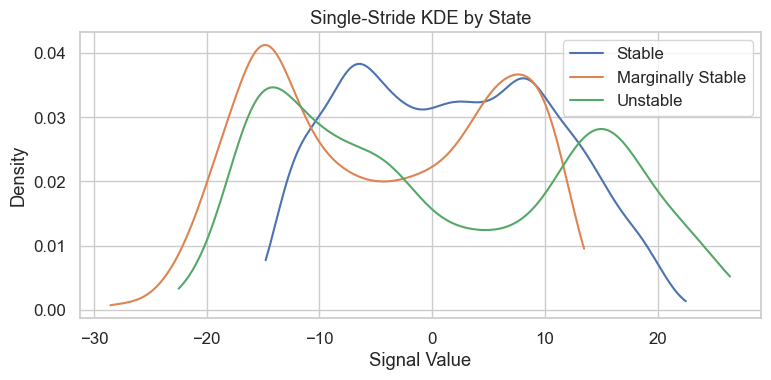

Generating faceted histograms...


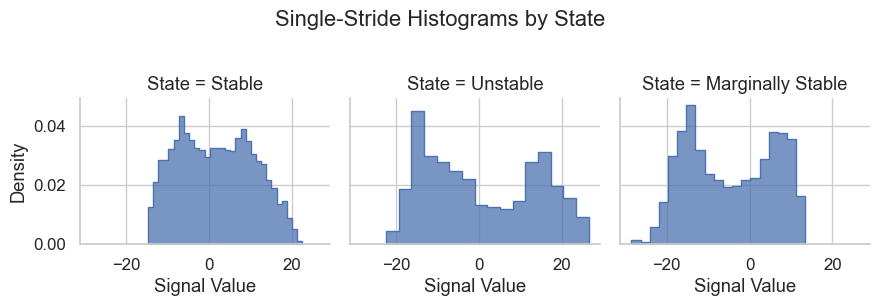

Generating per-stride histogram overlay...


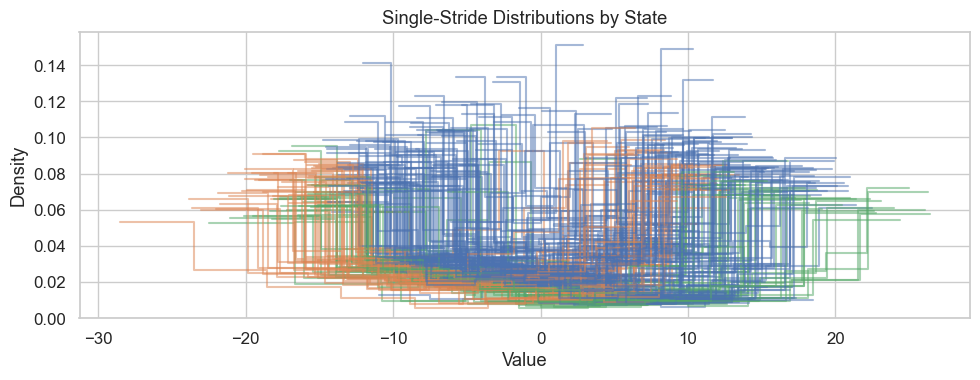

Generating time series with state overlay...


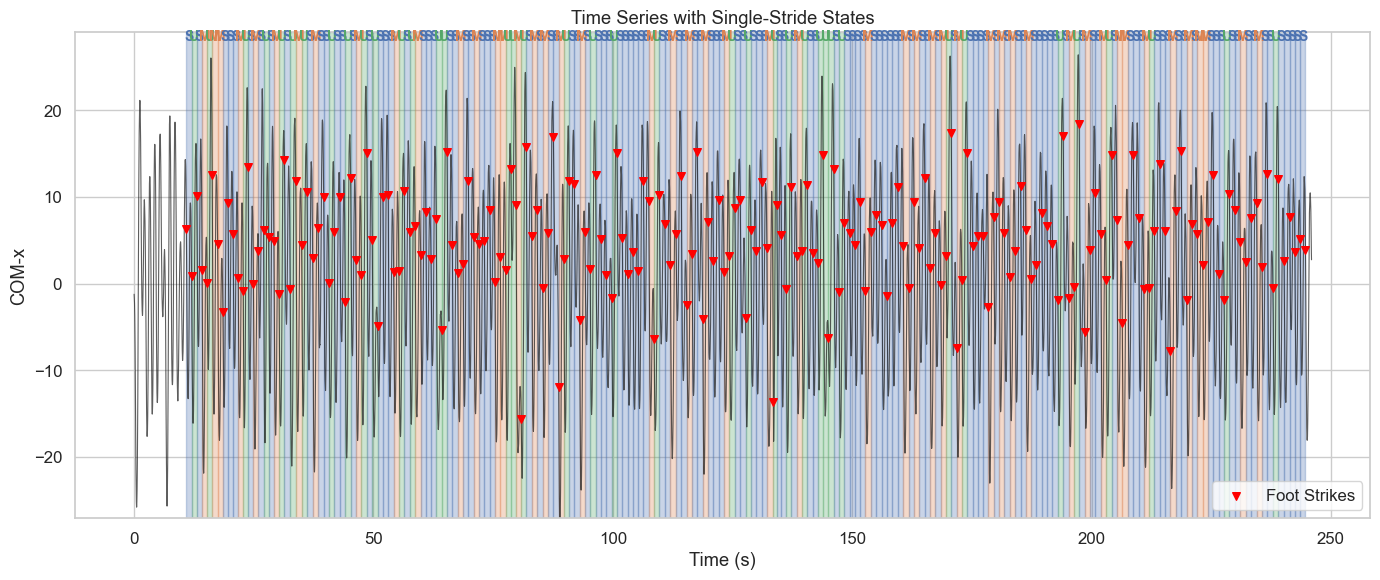


DISTRIBUTION-BASED MSM RESULTS

Total strides analyzed: 210
Average stride duration: 1.113 ± 0.043s

VALIDATION METRICS:
--------------------
GMM Reconstruction RMSE: 0.0882
  → Excellent GMM reconstruction quality
Clustering Silhouette Score: 0.172
  → Poor clustering - consider different parameters
Variance Explained by Clustering: 25.2%
  → Low variance explained - consider more states or different approach

TRANSITION ANALYSIS:
--------------------
Transition Matrix T:
[[0.521 0.339 0.14 ]
 [0.551 0.082 0.367]
 [0.795 0.103 0.103]]

Stationary Distribution Π:
[0.579 0.234 0.187]

Mean Dwell Times τ (strides):
[2.086 1.089 1.114]

STATE STATISTICS:
--------------------

Stable:
  Fraction of strides: 0.581
  Mean duration: 1.115s
  Duration std: 0.029s
  Histogram peak bin: 3
  Histogram entropy: 1.629

Marginally Stable:
  Fraction of strides: 0.233
  Mean duration: 1.121s
  Duration std: 0.047s
  Histogram peak bin: 5
  Histogram entropy: 1.672

Unstable:
  Fraction of strides: 0

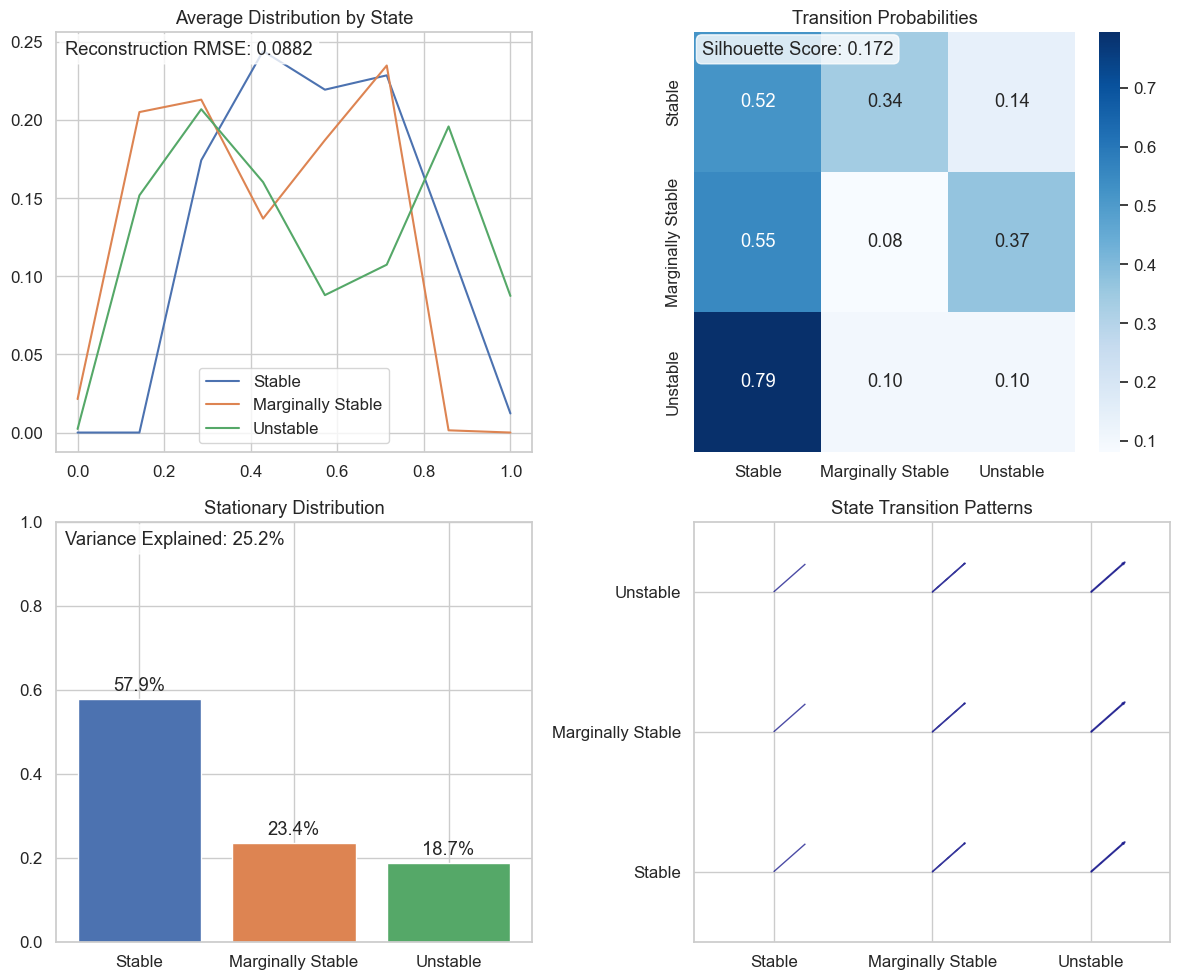


STATE SEQUENCE ANALYSIS

Found 139 state runs

Stable:
  Number of runs: 59
  Mean run length: 2.1 strides
  Max run length: 6 strides
  Min run length: 1 strides

Marginally Stable:
  Number of runs: 45
  Mean run length: 1.1 strides
  Max run length: 2 strides
  Min run length: 1 strides

Unstable:
  Number of runs: 35
  Mean run length: 1.1 strides
  Max run length: 3 strides
  Min run length: 1 strides

Generating validation plots...


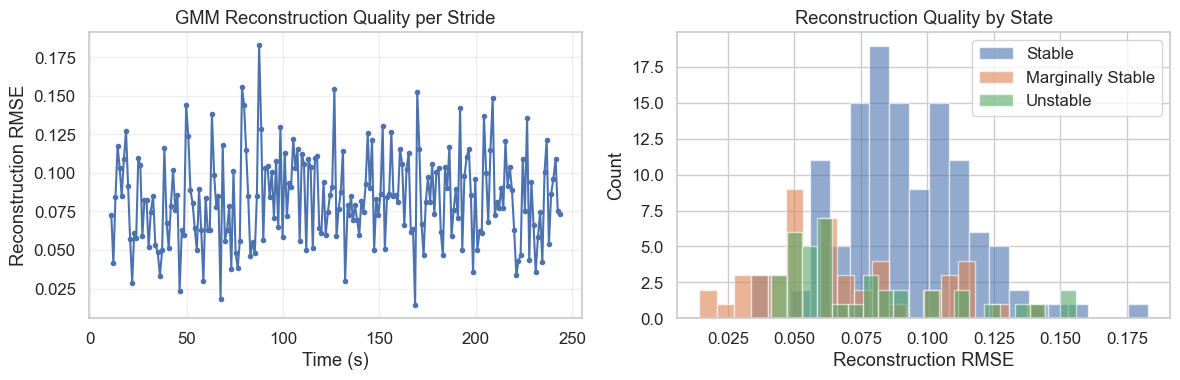


SUMMARY ASSESSMENT
Overall Quality Score: 3/6
Quality Notes:
  • Excellent GMM reconstruction
  • Poorly separated states
  • Low variance explained
  • Balanced state distribution

State Distribution: ['58.1%', '23.3%', '18.6%']
Dominant State: Stable


In [70]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
from preprocessing import preprocess_signal

def main():
    cwd = Path.cwd()
    marker_file = cwd.parent / ".." /"data"/"PBT"/"Elderly"/"03"/"markers.nc"
    events_file = cwd.parent / ".." /"data"/"PBT"/"Elderly"/"03" /"events.nc"
    # marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "markers.nc"
    # events_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) Load & preprocess COM-x
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs, poly_order=1,hp_cutoff=0.2, lp_cutoff=30.0)
    
    # Print signal characteristics for validation context
    print(f"Signal range: [{ts.min():.2f}, {ts.max():.2f}]")
    print(f"Signal std: {ts.std():.2f}")
    
    # 2) Extract foot strike events
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    
    avg_stride = np.mean(np.diff(strikes))
    win_samps = int(round(avg_stride * fs))
    print(f"Found {len(strikes)} foot strikes")
    print(f"Time range: {strikes[0]:.2f}s to {strikes[-1]:.2f}s")
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) Build & run DistributionMSM
    msm = DistributionMSM_Strides(
        patient_id="04_PWS", 
        n_states=3,
        n_bins=8, n_grid_points=100
    )
    
    msm.plot_gmm_reconstruction_error_distribution()
    # Fit the model
    msm.fit(ts, strikes, fs)
    df = msm.metrics_history
    states = df['state'].values
    
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}

    # 4) Overlaid kernel-density estimates (KDEs)
    print("\nGenerating KDE plots...")
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Gather all samples in strides of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(row.time*fs): int(row.time*fs + row.duration*fs)]
            for _, row in df.iloc[idxs].iterrows()
        ])
        if len(data) > 0:
            # Compute & plot KDE
            kde = gaussian_kde(data)
            xs = np.linspace(data.min(), data.max(), 200)
            plt.plot(xs, kde(xs), color=colors[st], label=label)
    
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Faceted histograms via Seaborn
    print("Generating faceted histograms...")
    # Build a "long" DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st = int(row.state)
        seg = ts[int(row.time * fs): int(row.time * fs) + int(row.duration * fs)]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value", stat="density", element="step", fill=True)
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()

    # 6) Per-stride histograms colored by state
    print("Generating per-stride histogram overlay...")
    plt.figure(figsize=(10, 4))
    for _, row in df.iterrows():
        st = int(row.state)
        start = int(row.time * fs)
        seg = ts[start: start + int(row.duration * fs)]
        sns.histplot(seg, bins=msm.n_bins, stat='density', element='step', 
                    fill=False, color=cmap[st], alpha=0.5)
    
    plt.title("Single-Stride Distributions by State")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # 7) Time series with S/M/U overlay
    print("Generating time series with state overlay...")
    letters = {0: "S", 1: "M", 2: "U"}
    times = np.arange(len(ts)) / fs
    plt.figure(figsize=(14, 6))
    plt.plot(times, ts, color='k', lw=0.8, alpha=0.7)
    
    for _, row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time + row.duration
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.3)
        plt.text((t0 + t1) / 2, ts.max() * 1.05, letters[st],
                ha='center', va='bottom', color=cmap[st], fontsize=10, fontweight='bold')
    
    # Mark foot strikes
    plt.scatter(strikes, np.interp(strikes, times, ts), 
               color='red', s=30, zorder=5, marker='v', label='Foot Strikes')
    
    plt.title("Time Series with Single-Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-x")
    plt.ylim(ts.min() * 0.95, ts.max() * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    print("\n" + "="*50)
    print("DISTRIBUTION-BASED MSM RESULTS")
    print("="*50)
    print(f"\nTotal strides analyzed: {len(df)}")
    print(f"Average stride duration: {df['duration'].mean():.3f} ± {df['duration'].std():.3f}s")
    
    # Print validation metrics first
    print("\nVALIDATION METRICS:")
    print("-" * 20)
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            print(f"GMM Reconstruction RMSE: {rmse:.4f}")
            # Interpret relative to signal characteristics
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.01:
                print("  → Excellent GMM reconstruction quality")
            elif relative_rmse < 0.05:
                print("  → Good GMM reconstruction quality")
            elif relative_rmse < 0.1:
                print("  → Reasonable GMM reconstruction quality")
            else:
                print("  → Poor GMM reconstruction quality")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            print(f"Clustering Silhouette Score: {sil:.3f}")
            if sil > 0.7:
                print("  → Strong, well-separated clusters")
            elif sil > 0.5:
                print("  → Reasonable clustering quality")
            elif sil > 0.25:
                print("  → Weak clustering - states may overlap")
            else:
                print("  → Poor clustering - consider different parameters")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            print(f"Variance Explained by Clustering: {var_exp:.1%}")
            if var_exp > 0.7:
                print("  → Clustering captures most histogram variance")
            elif var_exp > 0.5:
                print("  → Clustering captures reasonable variance")
            else:
                print("  → Low variance explained - consider more states or different approach")

    print("\nTRANSITION ANALYSIS:")
    print("-" * 20)
    print("Transition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (strides):")
    print(np.round(tau, 3))
    
    print("\nSTATE STATISTICS:")
    print("-" * 20)
    for i in range(msm.n_states):
        state_data = df[df['state'] == i]
        print(f"\n{msm.state_labels[i]}:")
        print(f"  Fraction of strides: {len(state_data)/len(df):.3f}")
        print(f"  Mean duration: {state_data['duration'].mean():.3f}s")
        print(f"  Duration std: {state_data['duration'].std():.3f}s")
        
        # Show mean histogram characteristics
        cols = [c for c in state_data.columns if c.startswith('bin_')]
        mean_hist = state_data[cols].mean().values
        print(f"  Histogram peak bin: {np.argmax(mean_hist)}")
        print(f"  Histogram entropy: {-np.sum(mean_hist * np.log(mean_hist + 1e-10)):.3f}")

    # 9) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()

    # 10) State sequence analysis
    print("\n" + "="*50)
    print("STATE SEQUENCE ANALYSIS")
    print("="*50)
    
    # Find runs of consecutive states
    state_runs = []
    current_state = states[0]
    run_start = 0
    
    for i in range(1, len(states)):
        if states[i] != current_state:
            state_runs.append({
                'state': current_state,
                'start_idx': run_start,
                'end_idx': i-1,
                'length': i - run_start,
                'start_time': df.iloc[run_start]['time'],
                'end_time': df.iloc[i-1]['time']
            })
            current_state = states[i]
            run_start = i
    
    # Add final run
    state_runs.append({
        'state': current_state,
        'start_idx': run_start,
        'end_idx': len(states)-1,
        'length': len(states) - run_start,
        'start_time': df.iloc[run_start]['time'],
        'end_time': df.iloc[-1]['time']
    })
    
    # Analyze runs
    print(f"\nFound {len(state_runs)} state runs")
    for state in range(msm.n_states):
        runs = [r for r in state_runs if r['state'] == state]
        if runs:
            lengths = [r['length'] for r in runs]
            print(f"\n{msm.state_labels[state]}:")
            print(f"  Number of runs: {len(runs)}")
            print(f"  Mean run length: {np.mean(lengths):.1f} strides")
            print(f"  Max run length: {np.max(lengths)} strides")
            print(f"  Min run length: {np.min(lengths)} strides")

    # 11) Additional validation plots
    print("\nGenerating validation plots...")
    
    # Plot reconstruction quality per stride
    if 'gmm_reconstruction_rmse_per_stride' in msm.validation_metrics:
        plt.figure(figsize=(12, 4))
        per_stride_rmse = msm.validation_metrics['gmm_reconstruction_rmse_per_stride']
        
        plt.subplot(1, 2, 1)
        plt.plot(df['time'], per_stride_rmse, 'o-', markersize=3)
        plt.xlabel('Time (s)')
        plt.ylabel('Reconstruction RMSE')
        plt.title('GMM Reconstruction Quality per Stride')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        for state in range(msm.n_states):
            state_mask = df['state'] == state
            state_rmse = per_stride_rmse[state_mask]
            if len(state_rmse) == 0:
                continue

            # Choose bins = min(requested, unique‐value count) or use 'auto'
            unique_vals = np.unique(state_rmse)
            nbins = min(20, len(unique_vals)) if len(unique_vals)>1 else 1

            plt.hist(
                state_rmse,
                bins=nbins,                     # adapt to data
                alpha=0.6,
                label=msm.state_labels[state],
                color=colors[state],
            )
            plt.xlabel('Reconstruction RMSE')
        plt.ylabel('Count')
        plt.title('Reconstruction Quality by State')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Summary statistics
    print("\n" + "="*50)
    print("SUMMARY ASSESSMENT")
    print("="*50)
    
    # Overall quality assessment
    quality_score = 0
    quality_notes = []
    
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.05:
                quality_score += 2
                quality_notes.append("Excellent GMM reconstruction")
            elif relative_rmse < 0.1:
                quality_score += 1
                quality_notes.append("Good GMM reconstruction")
            else:
                quality_notes.append("Poor GMM reconstruction")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            if sil > 0.5:
                quality_score += 2
                quality_notes.append("Well-separated states")
            elif sil > 0.25:
                quality_score += 1
                quality_notes.append("Moderately separated states")
            else:
                quality_notes.append("Poorly separated states")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            if var_exp > 0.6:
                quality_score += 1
                quality_notes.append("Good variance explained")
            else:
                quality_notes.append("Low variance explained")
    
    # Check if states are balanced
    state_fractions = [np.mean(states == i) for i in range(msm.n_states)]
    if min(state_fractions) > 0.1:  # All states have at least 10% of data
        quality_score += 1
        quality_notes.append("Balanced state distribution")
    else:
        quality_notes.append("Imbalanced state distribution")
    
    print(f"Overall Quality Score: {quality_score}/6")
    print("Quality Notes:")
    for note in quality_notes:
        print(f"  • {note}")
    
    print(f"\nState Distribution: {[f'{f:.1%}' for f in state_fractions]}")
    print(f"Dominant State: {msm.state_labels[np.argmax(state_fractions)]}")
    
    return msm, summary

if __name__ == "__main__":
    model, metrics = main()

### 12

Signal range: [-38.36, 33.77]
Signal std: 16.22
Found 243 foot strikes
Time range: 10.68s to 244.32s
Single-stride window = 97 samples (~0.97s)
No per‑stride GMM RMSE data.
Processing patient 04_PWS using stride-based histograms…
Created histograms from 242 valid strides
Average stride duration: 0.965s ± 0.045s
Identifying stability states via GMM…
GMM reconstruction RMSE: 0.0581
Clustering silhouette score: 0.204
Clustering quality: Poor clustering
Variance explained by clustering: 36.0%
Computing transition matrix…
Computing stationary distribution…

Stability metrics for 04_PWS:
  frac_state_0: 0.409
  frac_state_1: 0.306
  frac_state_2: 0.285
  gmm_reconstruction_rmse: 0.058
  clustering_silhouette_score: 0.204
  variance_explained_by_clustering: 0.360

Validation Summary:
  GMM reconstruction quality: RMSE = 0.0581
  Clustering quality: Silhouette = 0.204
  Variance explained by clustering: 36.0%

Generating KDE plots...


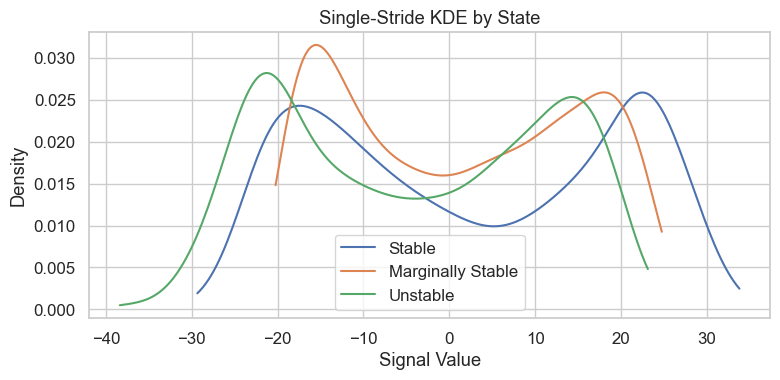

Generating faceted histograms...


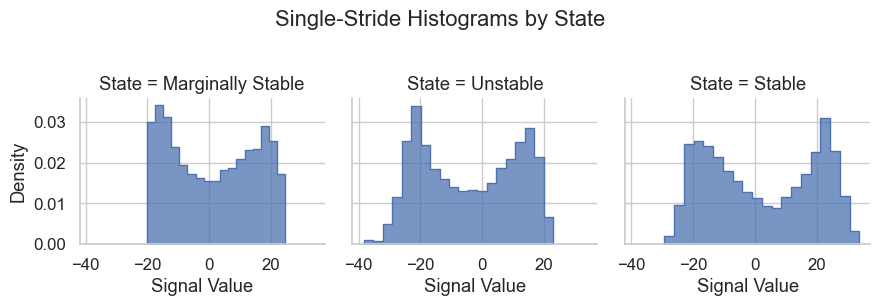

Generating per-stride histogram overlay...


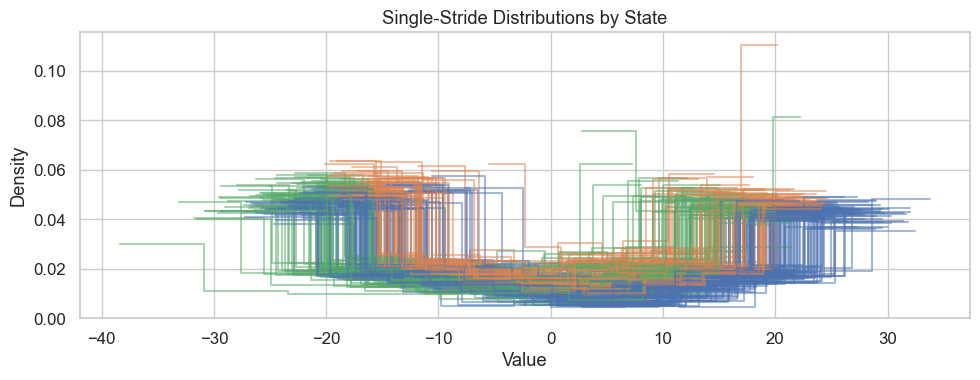

Generating time series with state overlay...


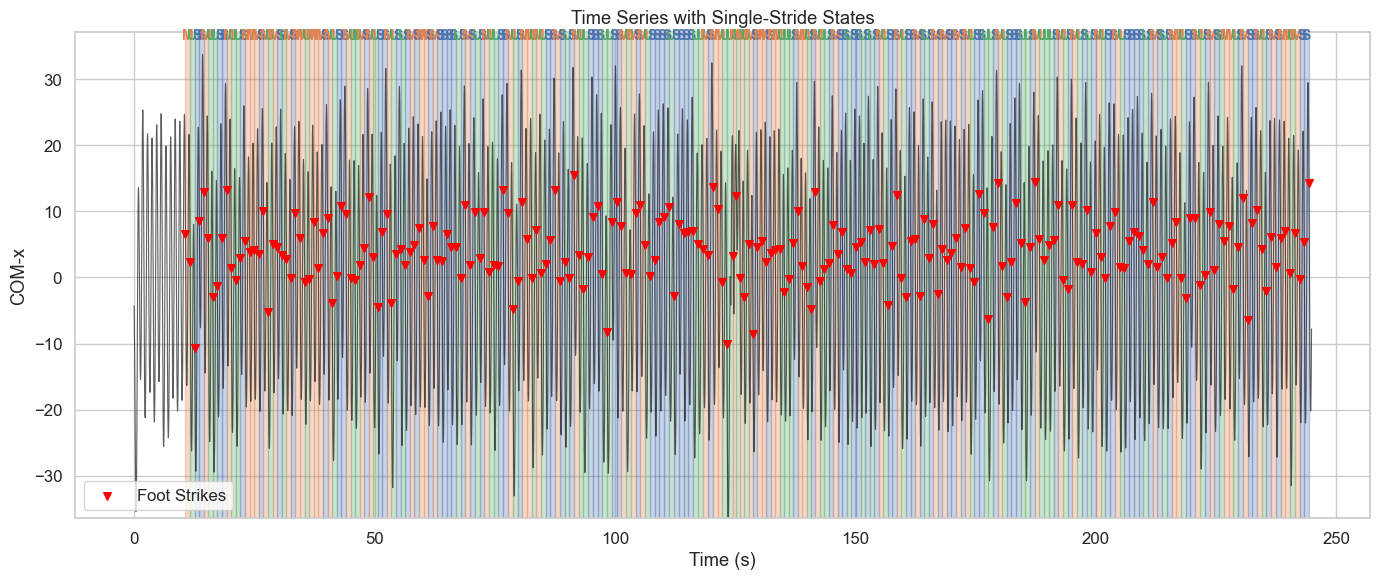


DISTRIBUTION-BASED MSM RESULTS

Total strides analyzed: 242
Average stride duration: 0.965 ± 0.045s

VALIDATION METRICS:
--------------------
GMM Reconstruction RMSE: 0.0581
  → Excellent GMM reconstruction quality
Clustering Silhouette Score: 0.204
  → Poor clustering - consider different parameters
Variance Explained by Clustering: 36.0%
  → Low variance explained - consider more states or different approach

TRANSITION ANALYSIS:
--------------------
Transition Matrix T:
[[0.337 0.48  0.184]
 [0.324 0.189 0.486]
 [0.609 0.174 0.217]]

Stationary Distribution Π:
[0.411 0.304 0.285]

Mean Dwell Times τ (strides):
[1.508 1.233 1.278]

STATE STATISTICS:
--------------------

Stable:
  Fraction of strides: 0.409
  Mean duration: 0.971s
  Duration std: 0.027s
  Histogram peak bin: 6
  Histogram entropy: 1.888

Marginally Stable:
  Fraction of strides: 0.306
  Mean duration: 0.953s
  Duration std: 0.046s
  Histogram peak bin: 2
  Histogram entropy: 1.588

Unstable:
  Fraction of strides: 0

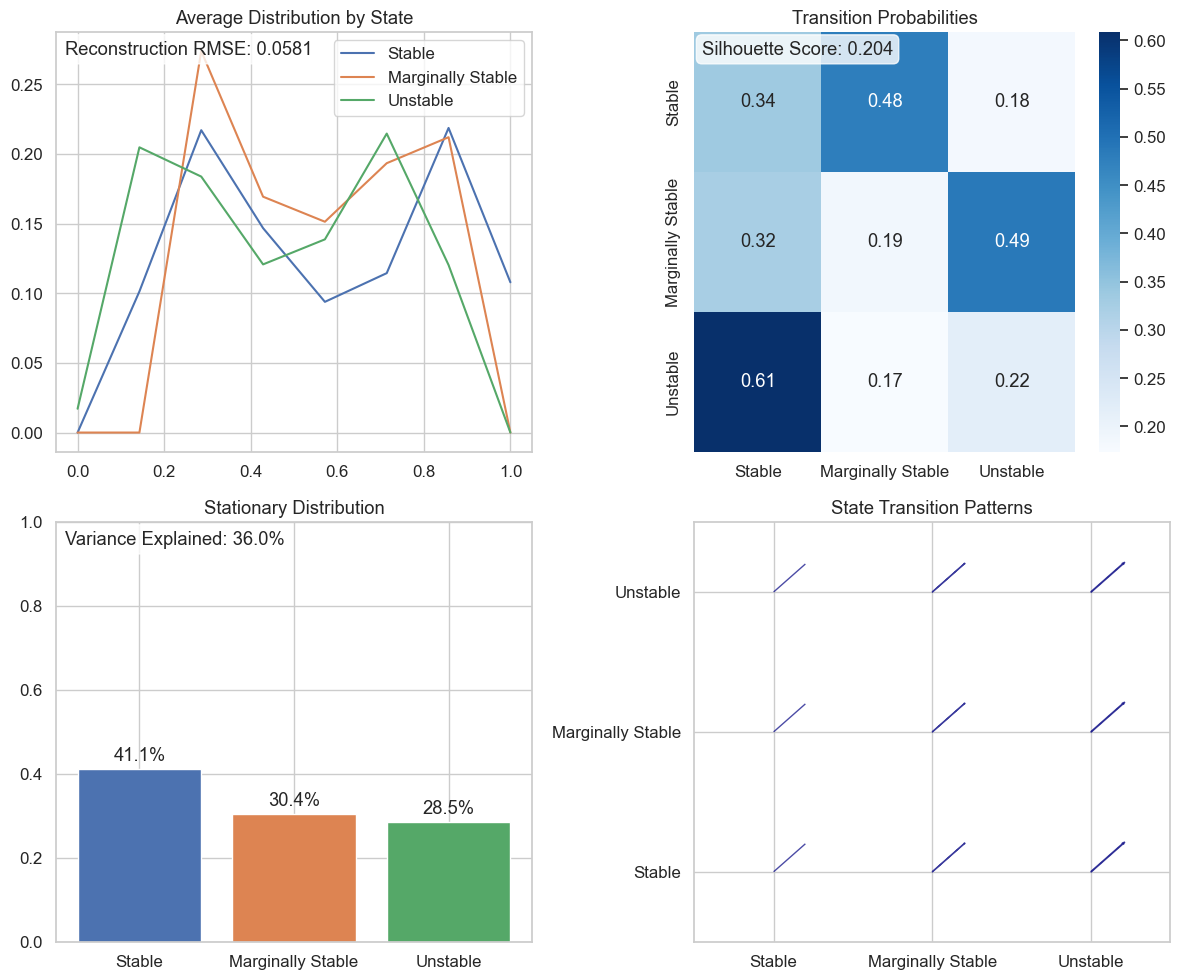


STATE SEQUENCE ANALYSIS

Found 180 state runs

Stable:
  Number of runs: 66
  Mean run length: 1.5 strides
  Max run length: 4 strides
  Min run length: 1 strides

Marginally Stable:
  Number of runs: 60
  Mean run length: 1.2 strides
  Max run length: 3 strides
  Min run length: 1 strides

Unstable:
  Number of runs: 54
  Mean run length: 1.3 strides
  Max run length: 3 strides
  Min run length: 1 strides

Generating validation plots...


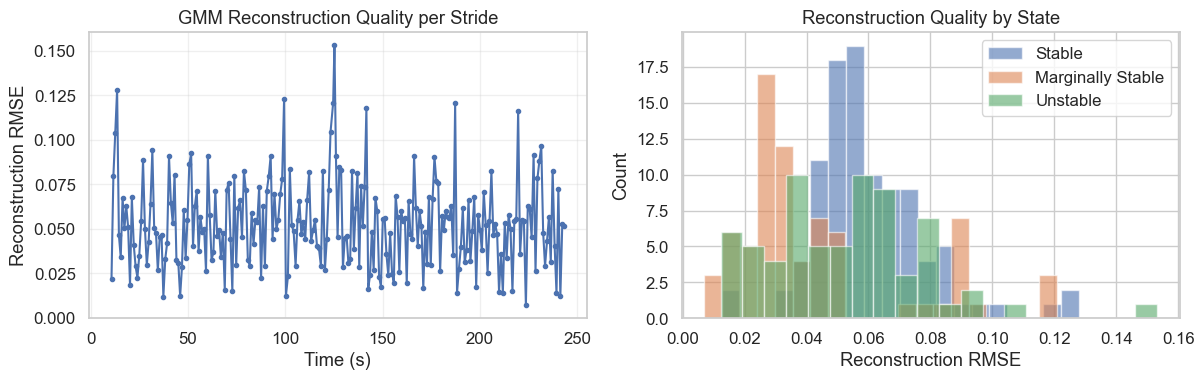


SUMMARY ASSESSMENT
Overall Quality Score: 3/6
Quality Notes:
  • Excellent GMM reconstruction
  • Poorly separated states
  • Low variance explained
  • Balanced state distribution

State Distribution: ['40.9%', '30.6%', '28.5%']
Dominant State: Stable


In [71]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.stats import gaussian_kde
from preprocessing import preprocess_signal

def main():
    cwd = Path.cwd()
    marker_file = cwd.parent / ".." /"data"/"PBT"/"Elderly"/"12"/"markers.nc"
    events_file = cwd.parent / ".." /"data"/"PBT"/"Elderly"/"12" /"events.nc"
    # marker_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "markers.nc"
    # events_file = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4"/ "events.nc"
    fs = 100.0

    # 1) Load & preprocess COM-x
    ds = xr.open_dataset(marker_file)
    da = ds["markers"] if "markers" in ds else ds
    raw = da.sel(channel="COM").sel(axis="x").values
    ts = preprocess_signal(raw, fs, poly_order=1,hp_cutoff=0.2, lp_cutoff=30.0)
    
    # Print signal characteristics for validation context
    print(f"Signal range: [{ts.min():.2f}, {ts.max():.2f}]")
    print(f"Signal std: {ts.std():.2f}")
    
    # 2) Extract foot strike events
    ev_ds = xr.open_dataset(events_file)
    ev_da = ev_ds["events"] if "events" in ev_ds else ev_ds
    df_ev = ev_da.to_dataframe().reset_index()
    strikes = np.sort(df_ev.query("label=='Foot Strike' & context=='Right' & time>=10")["time"].values)
    
    avg_stride = np.mean(np.diff(strikes))
    win_samps = int(round(avg_stride * fs))
    print(f"Found {len(strikes)} foot strikes")
    print(f"Time range: {strikes[0]:.2f}s to {strikes[-1]:.2f}s")
    print(f"Single-stride window = {win_samps} samples (~{avg_stride:.2f}s)")

    # 3) Build & run DistributionMSM
    msm = DistributionMSM_Strides(
        patient_id="04_PWS", 
        n_states=3,
        n_bins=8, n_grid_points=100
    )
    
    msm.plot_gmm_reconstruction_error_distribution()
    # Fit the model
    msm.fit(ts, strikes, fs)
    df = msm.metrics_history
    states = df['state'].values
    
    # Get colors and labels
    colors = sns.color_palette(n_colors=3)
    cmap = {i: colors[i] for i in range(3)}

    # 4) Overlaid kernel-density estimates (KDEs)
    print("\nGenerating KDE plots...")
    plt.figure(figsize=(8, 4))
    for st, label in msm.state_labels.items():
        # Gather all samples in strides of this state
        idxs = df.index[df.state == st]
        data = np.hstack([
            ts[int(row.time*fs): int(row.time*fs + row.duration*fs)]
            for _, row in df.iloc[idxs].iterrows()
        ])
        if len(data) > 0:
            # Compute & plot KDE
            kde = gaussian_kde(data)
            xs = np.linspace(data.min(), data.max(), 200)
            plt.plot(xs, kde(xs), color=colors[st], label=label)
    
    plt.xlabel("Signal Value")
    plt.ylabel("Density")
    plt.title("Single-Stride KDE by State")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Faceted histograms via Seaborn
    print("Generating faceted histograms...")
    # Build a "long" DataFrame of value / state pairs
    long = []
    for _, row in df.iterrows():
        st = int(row.state)
        seg = ts[int(row.time * fs): int(row.time * fs) + int(row.duration * fs)]
        long += [{'value': v, 'State': msm.state_labels[st]} for v in seg]
    long_df = pd.DataFrame(long)

    g = sns.FacetGrid(long_df, col="State", sharex=True, sharey=True, height=3)
    g.map(sns.histplot, "value", stat="density", element="step", fill=True)
    g.set_axis_labels("Signal Value", "Density")
    g.fig.suptitle("Single-Stride Histograms by State", y=1.02)
    plt.tight_layout()
    plt.show()

    # 6) Per-stride histograms colored by state
    print("Generating per-stride histogram overlay...")
    plt.figure(figsize=(10, 4))
    for _, row in df.iterrows():
        st = int(row.state)
        start = int(row.time * fs)
        seg = ts[start: start + int(row.duration * fs)]
        sns.histplot(seg, bins=msm.n_bins, stat='density', element='step', 
                    fill=False, color=cmap[st], alpha=0.5)
    
    plt.title("Single-Stride Distributions by State")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    # 7) Time series with S/M/U overlay
    print("Generating time series with state overlay...")
    letters = {0: "S", 1: "M", 2: "U"}
    times = np.arange(len(ts)) / fs
    plt.figure(figsize=(14, 6))
    plt.plot(times, ts, color='k', lw=0.8, alpha=0.7)
    
    for _, row in df.iterrows():
        st = int(row.state)
        t0, t1 = row.time, row.time + row.duration
        plt.axvspan(t0, t1, color=cmap[st], alpha=0.3)
        plt.text((t0 + t1) / 2, ts.max() * 1.05, letters[st],
                ha='center', va='bottom', color=cmap[st], fontsize=10, fontweight='bold')
    
    # Mark foot strikes
    plt.scatter(strikes, np.interp(strikes, times, ts), 
               color='red', s=30, zorder=5, marker='v', label='Foot Strikes')
    
    plt.title("Time Series with Single-Stride States")
    plt.xlabel("Time (s)")
    plt.ylabel("COM-x")
    plt.ylim(ts.min() * 0.95, ts.max() * 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 8) Compute and print metrics
    T = msm.transition_matrix
    pi = msm.stationary_dist
    tau = msm.compute_mean_dwell_times()
    summary = msm.compute_stability_metrics()

    print("\n" + "="*50)
    print("DISTRIBUTION-BASED MSM RESULTS")
    print("="*50)
    print(f"\nTotal strides analyzed: {len(df)}")
    print(f"Average stride duration: {df['duration'].mean():.3f} ± {df['duration'].std():.3f}s")
    
    # Print validation metrics first
    print("\nVALIDATION METRICS:")
    print("-" * 20)
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            print(f"GMM Reconstruction RMSE: {rmse:.4f}")
            # Interpret relative to signal characteristics
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.01:
                print("  → Excellent GMM reconstruction quality")
            elif relative_rmse < 0.05:
                print("  → Good GMM reconstruction quality")
            elif relative_rmse < 0.1:
                print("  → Reasonable GMM reconstruction quality")
            else:
                print("  → Poor GMM reconstruction quality")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            print(f"Clustering Silhouette Score: {sil:.3f}")
            if sil > 0.7:
                print("  → Strong, well-separated clusters")
            elif sil > 0.5:
                print("  → Reasonable clustering quality")
            elif sil > 0.25:
                print("  → Weak clustering - states may overlap")
            else:
                print("  → Poor clustering - consider different parameters")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            print(f"Variance Explained by Clustering: {var_exp:.1%}")
            if var_exp > 0.7:
                print("  → Clustering captures most histogram variance")
            elif var_exp > 0.5:
                print("  → Clustering captures reasonable variance")
            else:
                print("  → Low variance explained - consider more states or different approach")

    print("\nTRANSITION ANALYSIS:")
    print("-" * 20)
    print("Transition Matrix T:")
    print(np.round(T, 3))
    print("\nStationary Distribution Π:")
    print(np.round(pi, 3))
    print("\nMean Dwell Times τ (strides):")
    print(np.round(tau, 3))
    
    print("\nSTATE STATISTICS:")
    print("-" * 20)
    for i in range(msm.n_states):
        state_data = df[df['state'] == i]
        print(f"\n{msm.state_labels[i]}:")
        print(f"  Fraction of strides: {len(state_data)/len(df):.3f}")
        print(f"  Mean duration: {state_data['duration'].mean():.3f}s")
        print(f"  Duration std: {state_data['duration'].std():.3f}s")
        
        # Show mean histogram characteristics
        cols = [c for c in state_data.columns if c.startswith('bin_')]
        mean_hist = state_data[cols].mean().values
        print(f"  Histogram peak bin: {np.argmax(mean_hist)}")
        print(f"  Histogram entropy: {-np.sum(mean_hist * np.log(mean_hist + 1e-10)):.3f}")

    # 9) Show built-in visualizations
    print("\nGenerating summary visualizations...")
    msm.visualize_patient_analysis()

    # 10) State sequence analysis
    print("\n" + "="*50)
    print("STATE SEQUENCE ANALYSIS")
    print("="*50)
    
    # Find runs of consecutive states
    state_runs = []
    current_state = states[0]
    run_start = 0
    
    for i in range(1, len(states)):
        if states[i] != current_state:
            state_runs.append({
                'state': current_state,
                'start_idx': run_start,
                'end_idx': i-1,
                'length': i - run_start,
                'start_time': df.iloc[run_start]['time'],
                'end_time': df.iloc[i-1]['time']
            })
            current_state = states[i]
            run_start = i
    
    # Add final run
    state_runs.append({
        'state': current_state,
        'start_idx': run_start,
        'end_idx': len(states)-1,
        'length': len(states) - run_start,
        'start_time': df.iloc[run_start]['time'],
        'end_time': df.iloc[-1]['time']
    })
    
    # Analyze runs
    print(f"\nFound {len(state_runs)} state runs")
    for state in range(msm.n_states):
        runs = [r for r in state_runs if r['state'] == state]
        if runs:
            lengths = [r['length'] for r in runs]
            print(f"\n{msm.state_labels[state]}:")
            print(f"  Number of runs: {len(runs)}")
            print(f"  Mean run length: {np.mean(lengths):.1f} strides")
            print(f"  Max run length: {np.max(lengths)} strides")
            print(f"  Min run length: {np.min(lengths)} strides")

    # 11) Additional validation plots
    print("\nGenerating validation plots...")
    
    # Plot reconstruction quality per stride
    if 'gmm_reconstruction_rmse_per_stride' in msm.validation_metrics:
        plt.figure(figsize=(12, 4))
        per_stride_rmse = msm.validation_metrics['gmm_reconstruction_rmse_per_stride']
        
        plt.subplot(1, 2, 1)
        plt.plot(df['time'], per_stride_rmse, 'o-', markersize=3)
        plt.xlabel('Time (s)')
        plt.ylabel('Reconstruction RMSE')
        plt.title('GMM Reconstruction Quality per Stride')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        for state in range(msm.n_states):
            state_mask = df['state'] == state
            state_rmse = per_stride_rmse[state_mask]
            if len(state_rmse) == 0:
                continue

            # Choose bins = min(requested, unique‐value count) or use 'auto'
            unique_vals = np.unique(state_rmse)
            nbins = min(20, len(unique_vals)) if len(unique_vals)>1 else 1

            plt.hist(
                state_rmse,
                bins=nbins,                     # adapt to data
                alpha=0.6,
                label=msm.state_labels[state],
                color=colors[state],
            )
            plt.xlabel('Reconstruction RMSE')
        plt.ylabel('Count')
        plt.title('Reconstruction Quality by State')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Summary statistics
    print("\n" + "="*50)
    print("SUMMARY ASSESSMENT")
    print("="*50)
    
    # Overall quality assessment
    quality_score = 0
    quality_notes = []
    
    if 'gmm_reconstruction_rmse' in msm.validation_metrics:
        rmse = msm.validation_metrics['gmm_reconstruction_rmse']
        if not np.isnan(rmse):
            signal_range = ts.max() - ts.min()
            relative_rmse = rmse / signal_range
            if relative_rmse < 0.05:
                quality_score += 2
                quality_notes.append("Excellent GMM reconstruction")
            elif relative_rmse < 0.1:
                quality_score += 1
                quality_notes.append("Good GMM reconstruction")
            else:
                quality_notes.append("Poor GMM reconstruction")
    
    if 'clustering_silhouette_score' in msm.validation_metrics:
        sil = msm.validation_metrics['clustering_silhouette_score']
        if not np.isnan(sil):
            if sil > 0.5:
                quality_score += 2
                quality_notes.append("Well-separated states")
            elif sil > 0.25:
                quality_score += 1
                quality_notes.append("Moderately separated states")
            else:
                quality_notes.append("Poorly separated states")
    
    if 'variance_explained_by_clustering' in msm.validation_metrics:
        var_exp = msm.validation_metrics['variance_explained_by_clustering']
        if not np.isnan(var_exp):
            if var_exp > 0.6:
                quality_score += 1
                quality_notes.append("Good variance explained")
            else:
                quality_notes.append("Low variance explained")
    
    # Check if states are balanced
    state_fractions = [np.mean(states == i) for i in range(msm.n_states)]
    if min(state_fractions) > 0.1:  # All states have at least 10% of data
        quality_score += 1
        quality_notes.append("Balanced state distribution")
    else:
        quality_notes.append("Imbalanced state distribution")
    
    print(f"Overall Quality Score: {quality_score}/6")
    print("Quality Notes:")
    for note in quality_notes:
        print(f"  • {note}")
    
    print(f"\nState Distribution: {[f'{f:.1%}' for f in state_fractions]}")
    print(f"Dominant State: {msm.state_labels[np.argmax(state_fractions)]}")
    
    return msm, summary

if __name__ == "__main__":
    model, metrics = main()